# Fraud detection

This work focuses on fraud detection and involves the use of classification models.
The dataset was artificially created for the Kaggle competition: [Playground Series - Season 3, Episode 4](https://www.kaggle.com/competitions/playground-series-s3e4). The target feature is Class: 0 is a normal transaction, 1 has fraud detection.

I can suggest that the dataset will have imbalanced classes - with fewer fraud cases than normal transactions. This is the first problem to struggle - I have to aplly class weighting.
The second problem is that feature names are hidden - making it more difficult to extract meaningful features.

## Install packages

In [3]:
!pip install scikit-learn==1.6.1
!pip install pandas==2.2.3
!pip install numpy==1.26.4
!pip install matplotlib==3.8.4
!pip install seaborn==0.13.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 84.2 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 84.0 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.5
    Uninstalling matplotlib-3.7.5:
      Successfully uninstalled matplotlib-3.7.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.2
    Uninstalling sea

In [4]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import RocCurveDisplay, roc_curve, auc

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import TargetEncoder

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier
import sklearn.tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier


from sklearn.calibration import CalibrationDisplay
from sklearn.calibration import calibration_curve

In [5]:
plt.style.use('bmh')

In [6]:
file = r'/kaggle/input/playground-series-s3e4/train.csv'

# EDA

In [5]:
data_eda = pd.read_csv(file, index_col = 'id')

In [6]:
data_eda.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,0.742144,0.108782,-1.070243,-0.234910,-1.099360,0.502467,0.169318,0.065688,-0.306957,-0.323800,0.103348,-0.292969,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,-0.109948,0.908773,0.836798,-0.056580,-0.120990,-0.144028,-0.039582,1.653057,-0.253599,-0.814354,0.716784,0.065717,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,-0.042027,-0.818383,-0.376512,-0.226546,-0.552869,-0.886466,-0.180890,0.230286,0.590579,-0.321590,-0.433959,-0.021375,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,0.885838,-0.007527,0.637441,0.676960,-1.504823,0.554039,-0.824356,-0.527267,-0.095838,-0.312519,0.642659,-0.340089,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,0.692665,-0.097495,1.338869,1.391399,-0.128167,-0.081836,0.100548,-0.338937,0.090864,-0.423645,-0.731939,-0.203628,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


In [7]:
#really imbalanced classes

data_eda.Class.value_counts(True) 

Class
0    0.99786
1    0.00214
Name: proportion, dtype: float64

In [8]:
#there are no N/A features

data_eda.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 219129 entries, 0 to 219128
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    219129 non-null  float64
 1   V1      219129 non-null  float64
 2   V2      219129 non-null  float64
 3   V3      219129 non-null  float64
 4   V4      219129 non-null  float64
 5   V5      219129 non-null  float64
 6   V6      219129 non-null  float64
 7   V7      219129 non-null  float64
 8   V8      219129 non-null  float64
 9   V9      219129 non-null  float64
 10  V10     219129 non-null  float64
 11  V11     219129 non-null  float64
 12  V12     219129 non-null  float64
 13  V13     219129 non-null  float64
 14  V14     219129 non-null  float64
 15  V15     219129 non-null  float64
 16  V16     219129 non-null  float64
 17  V17     219129 non-null  float64
 18  V18     219129 non-null  float64
 19  V19     219129 non-null  float64
 20  V20     219129 non-null  float64
 21  V21     219129 

In [9]:
#there are no constant features
data_eda.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000
mean,62377.415376,0.096008,0.048345,0.592102,0.069273,-0.161555,0.133688,-0.128224,0.149534,-0.048337,-0.039758,0.153632,-0.061038,0.014330,0.067649,0.108643,0.013650,0.036815,-0.033927,-0.008302,0.009708,-0.031064,-0.050852,-0.050531,-0.002992,0.124005,0.009881,0.014034,0.017313,66.359803,0.002140
std,25620.348569,1.395425,1.159805,1.132884,1.253125,1.069530,1.202411,0.817207,0.716212,1.054143,0.821889,0.976946,0.998470,1.039145,0.801335,0.891613,0.786654,0.691709,0.784454,0.739928,0.439521,0.422777,0.597812,0.318175,0.593100,0.406741,0.473867,0.233355,0.164859,150.795017,0.046214
min,0.000000,-29.807725,-44.247914,-19.722872,-5.263650,-37.591259,-25.659750,-31.179799,-28.903442,-8.756951,-22.092656,-4.190145,-16.180165,-4.373778,-15.585021,-4.155728,-11.778839,-20.756768,-7.456060,-4.281628,-18.679066,-14.689621,-8.748979,-11.958588,-2.836285,-3.958591,-1.858672,-9.234767,-4.551680,0.000000,0.000000
25%,47933.000000,-0.846135,-0.573728,-0.027154,-0.769256,-0.847346,-0.631835,-0.646730,-0.095948,-0.711444,-0.499563,-0.576969,-0.476890,-0.671601,-0.329905,-0.461596,-0.461077,-0.406675,-0.496990,-0.463035,-0.167927,-0.190418,-0.473099,-0.174478,-0.332540,-0.126080,-0.318330,-0.050983,-0.009512,5.990000,0.000000
50%,63189.000000,0.385913,0.046937,0.735895,0.064856,-0.229929,-0.087778,-0.098970,0.111219,-0.131323,-0.106034,0.090545,0.087649,-0.016837,0.049266,0.178975,0.054550,-0.013949,-0.039451,-0.002935,-0.037702,-0.042858,-0.032856,-0.063307,0.038708,0.145934,-0.086388,0.015905,0.022163,21.900000,0.000000
75%,77519.000000,1.190661,0.814145,1.306110,0.919353,0.356856,0.482388,0.385567,0.390976,0.583715,0.403967,0.917392,0.608480,0.695547,0.460837,0.791255,0.531777,0.410978,0.446448,0.455718,0.126750,0.109187,0.354910,0.060221,0.394566,0.402926,0.253869,0.076814,0.066987,68.930000,0.000000
max,120580.000000,2.430494,16.068473,6.145578,12.547997,34.581260,16.233967,39.824099,18.270586,13.423914,15.878405,9.417789,5.406614,5.976265,6.078453,4.693323,5.834992,8.845303,4.847887,4.090974,15.407839,22.062945,6.163541,12.734391,4.572739,3.111624,3.402344,13.123618,23.263746,7475.000000,1.000000


In [10]:
#there no categorical features 

for col in data_eda.columns:
    print(col, data_eda[col].nunique()/data_eda.shape[0])

Time 0.1681429660154521
V1 0.9935836881471645
V2 0.9936110692788266
V3 0.9934787271424594
V4 0.9935471799716149
V5 0.9933007497866554
V6 0.9929949938164278
V7 0.9936384504104888
V8 0.9933828931816419
V9 0.9933920202255293
V10 0.9935791246252208
V11 0.9933874567035855
V12 0.9936567044982636
V13 0.9937525384590812
V14 0.9935973787129956
V15 0.993574561103277
V16 0.9937023397177005
V17 0.9936658315421509
V18 0.9935973787129956
V19 0.9937069032396443
V20 0.9936703950640947
V21 0.9938483724198988
V22 0.9937160302835316
V23 0.9938574994637862
V24 0.9934194013571914
V25 0.9937571019810248
V26 0.9938027372004619
V27 0.9937251573274191
V28 0.9937434114151938
Amount 0.08937657726727179
Class 9.127043887390532e-06


In [11]:
# Time --> Day & Hour

#60*60*24 = 86400 seconds in a day
next_day_idx = data_eda[data_eda['Time'] > 86400-1].index  #indexes of transaction on the 2nd day 

data_eda['Day'] = np.zeros(data_eda.shape[0])
data_eda.loc[next_day_idx, 'Day'] = 1

data_eda.loc[next_day_idx, 'Time'] -= 86400

data_eda['Hour'] = data_eda['Time'] // 3600
data_eda = data_eda.drop('Time', axis = 1)

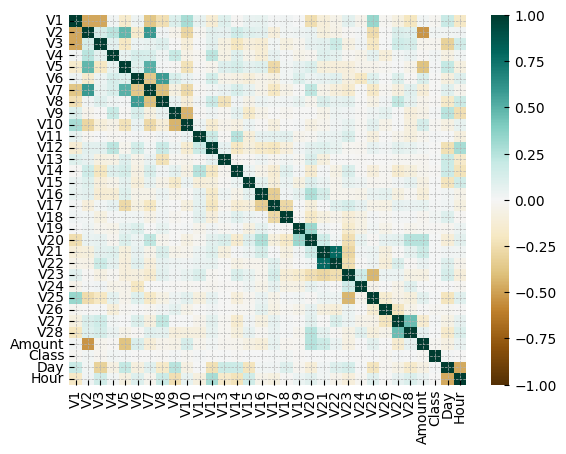

In [12]:
# Correlation check – using Spearman correlation function to find nonlinear correlation

fig = plt.Figure()
sns.heatmap(data_eda.corr(method = 'spearman'), 
            cmap = 'BrBG',  vmin = -1, vmax = 1,
            xticklabels = True,  yticklabels = True)
plt.show()

In [13]:
def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5, method = 'pearson'):
    au_corr = df.corr(method = method).abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top 5 Absolute Correlations: Spearman")
print(get_top_abs_correlations(data_eda, 5, 'spearman'))
print()
print("Top 2 Absolute Correlation: Pearson")
print(get_top_abs_correlations(data_eda, 5))

Top 5 Absolute Correlations: Spearman
V21  V22       0.783176
V2   V7        0.586425
V6   V8        0.579986
V2   Amount    0.534607
V5   V7        0.505057
dtype: float64

Top 2 Absolute Correlation: Pearson
V2   Amount    0.563721
V20  Amount    0.531469
Day  Hour      0.511015
V12  Hour      0.420830
V3   Day       0.349480
dtype: float64


In [14]:
# there are no strong correlations as per Pearson method, 
# there is only one correlation as per Sperman method (but it is ok - it is not over 0.8)
#! There is NO correlations with target

In [ ]:
# Compare normal and fraud classes
# Violin plots is a more powerful version of boxplots because they also show the distribution

In [15]:
fraud = data_eda[data_eda['Class'] ==1]
normal = data_eda[data_eda['Class'] !=1]

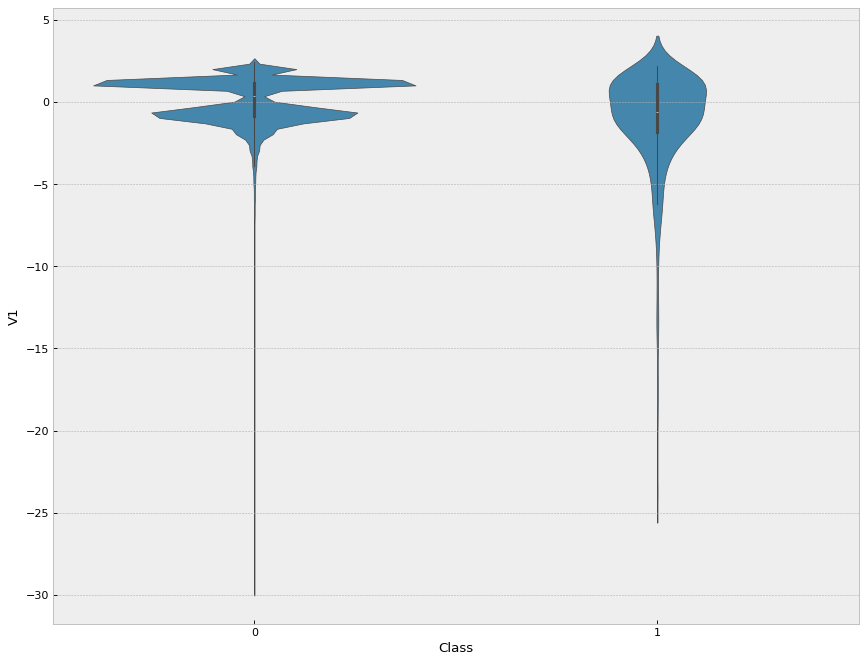

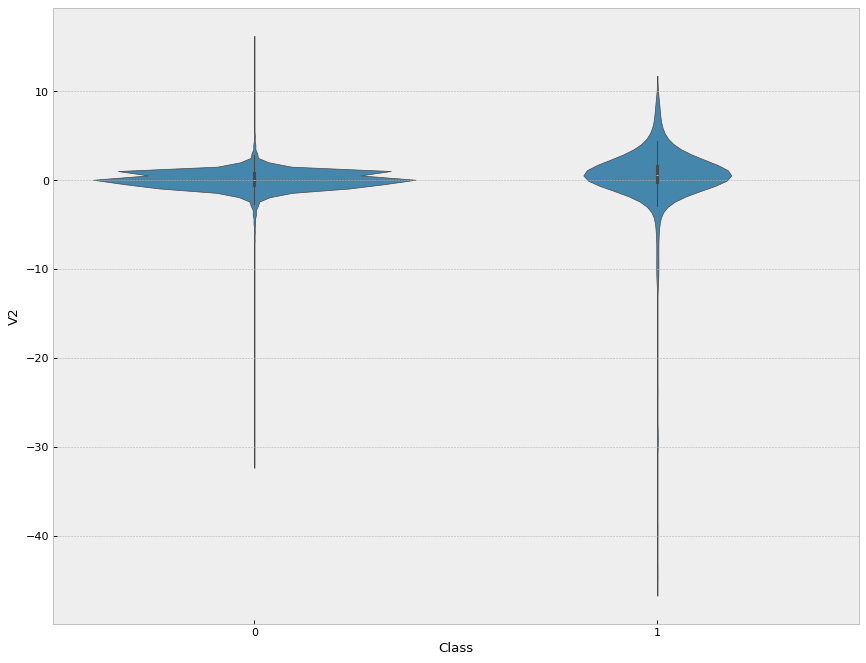

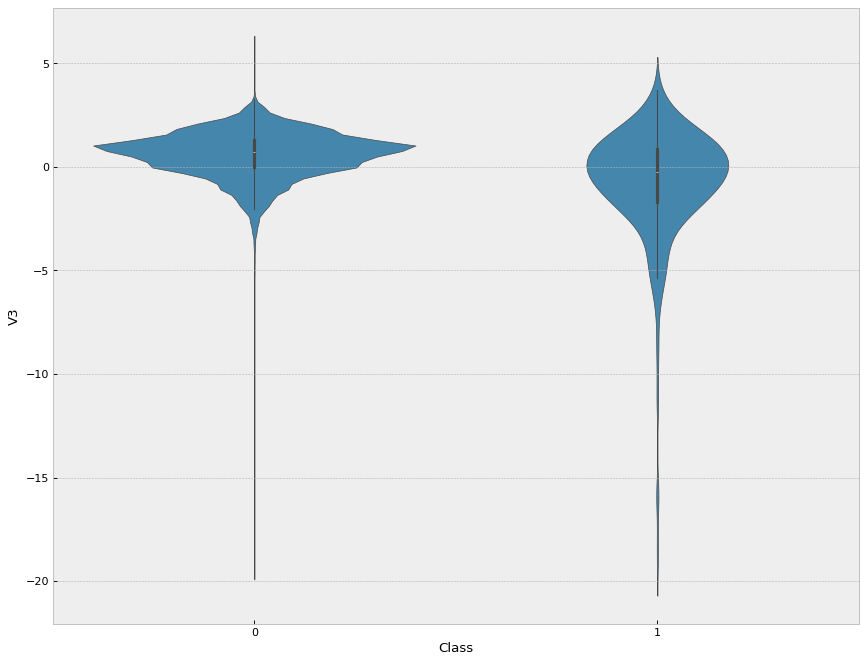

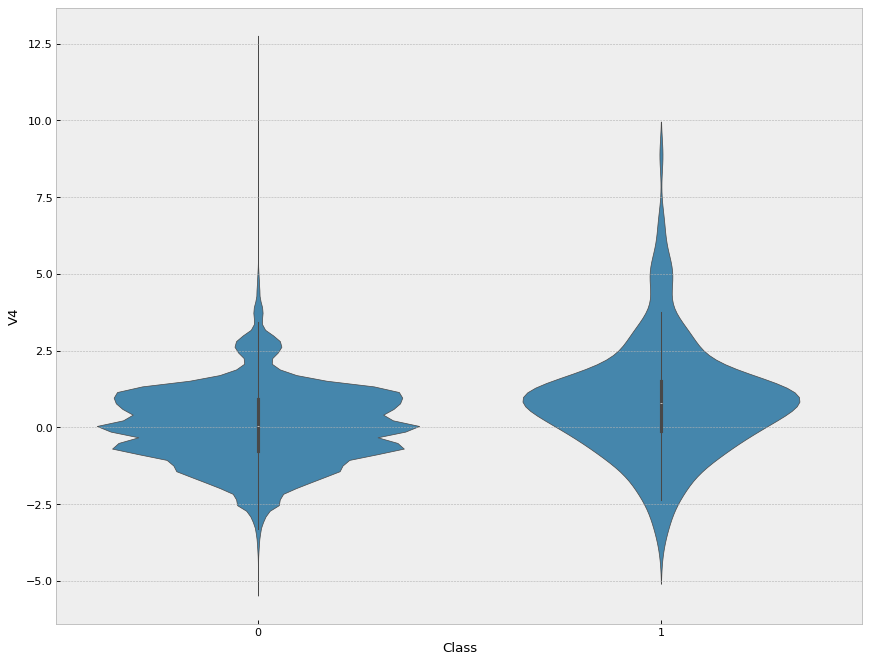

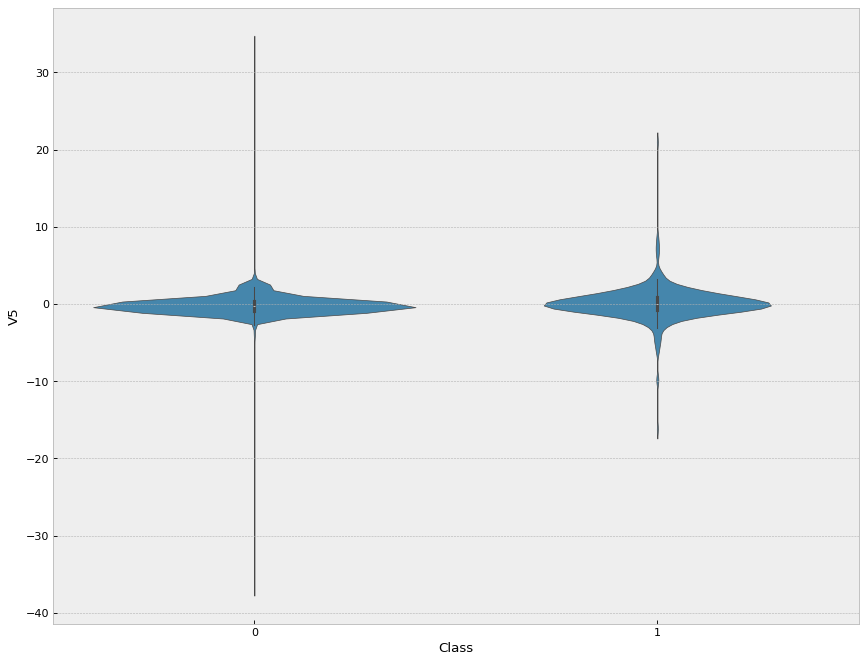

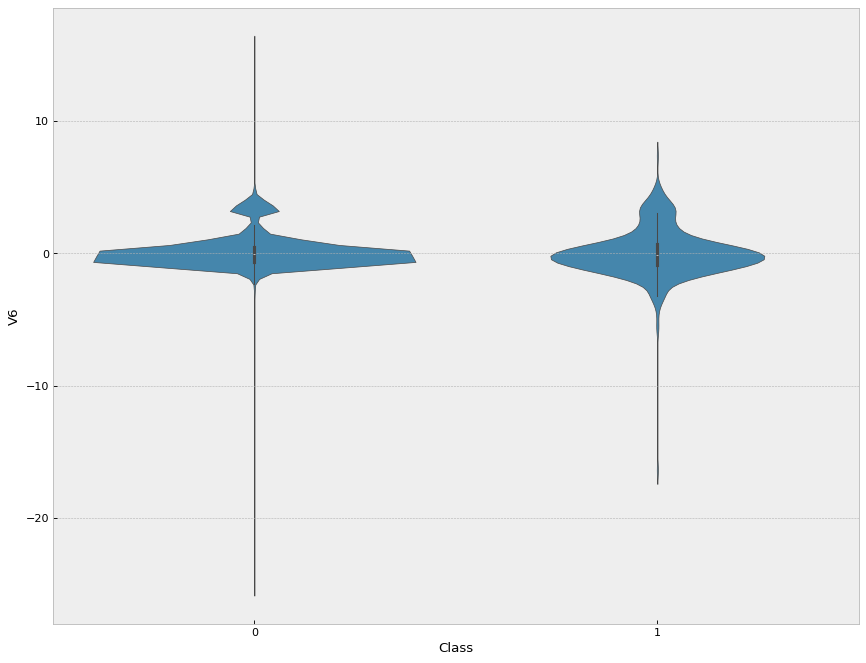

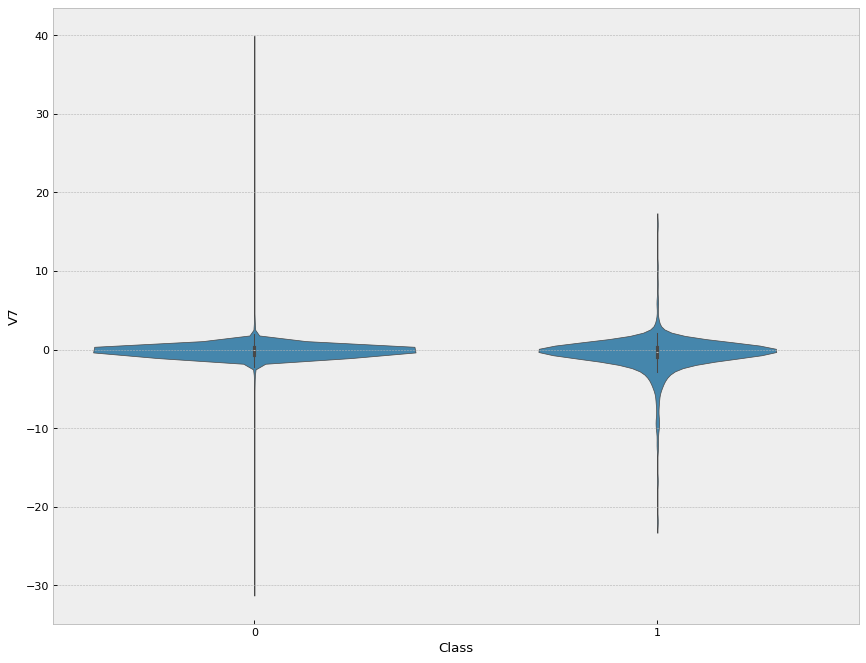

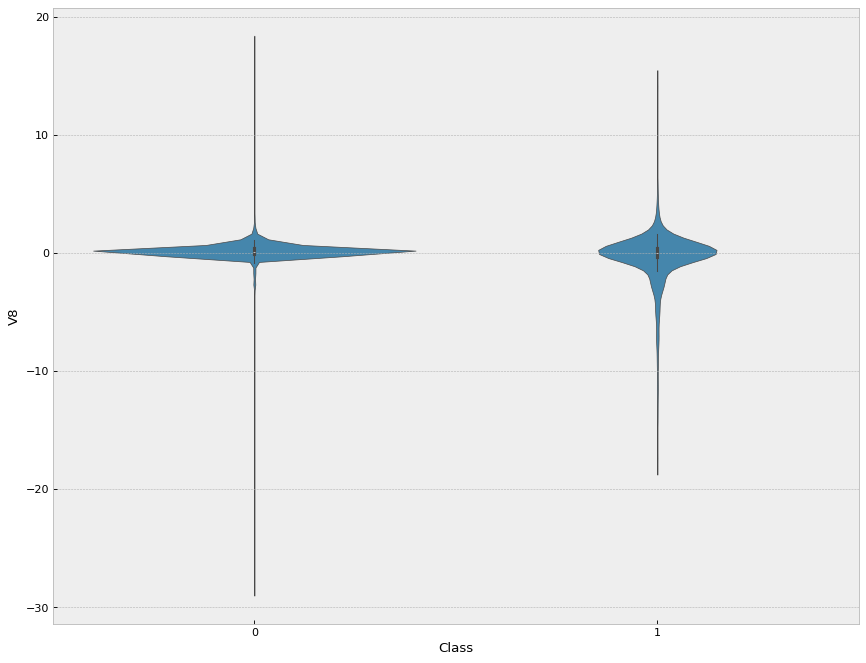

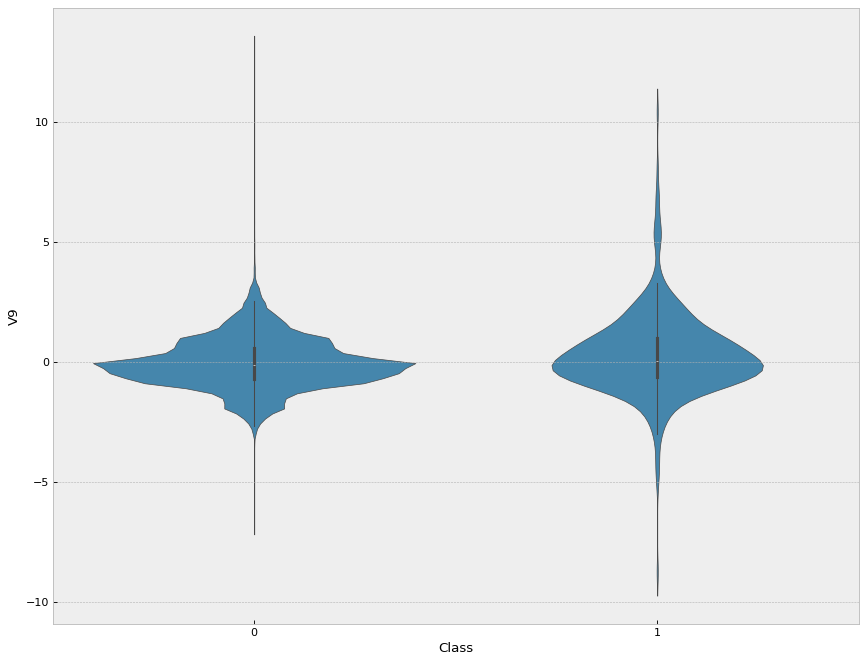

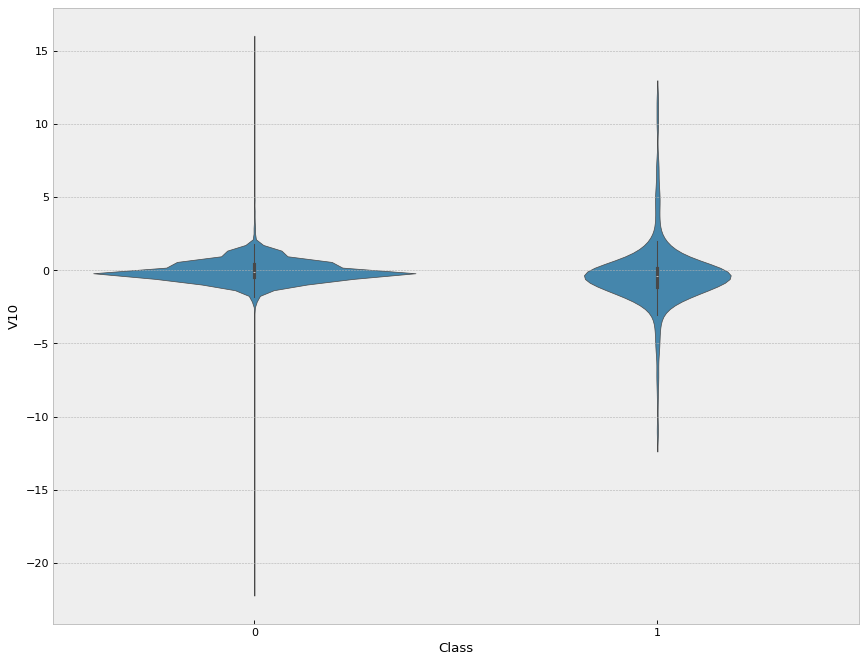

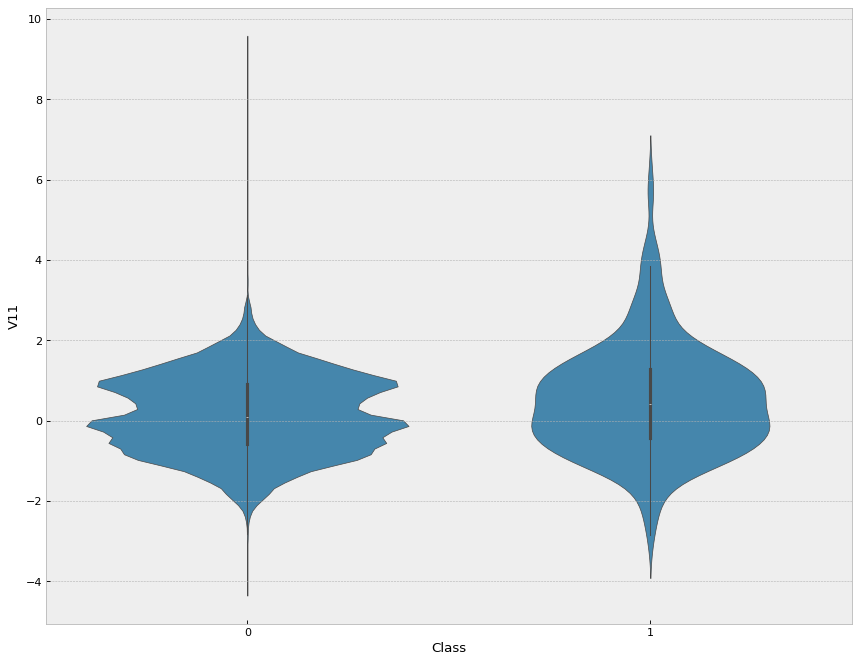

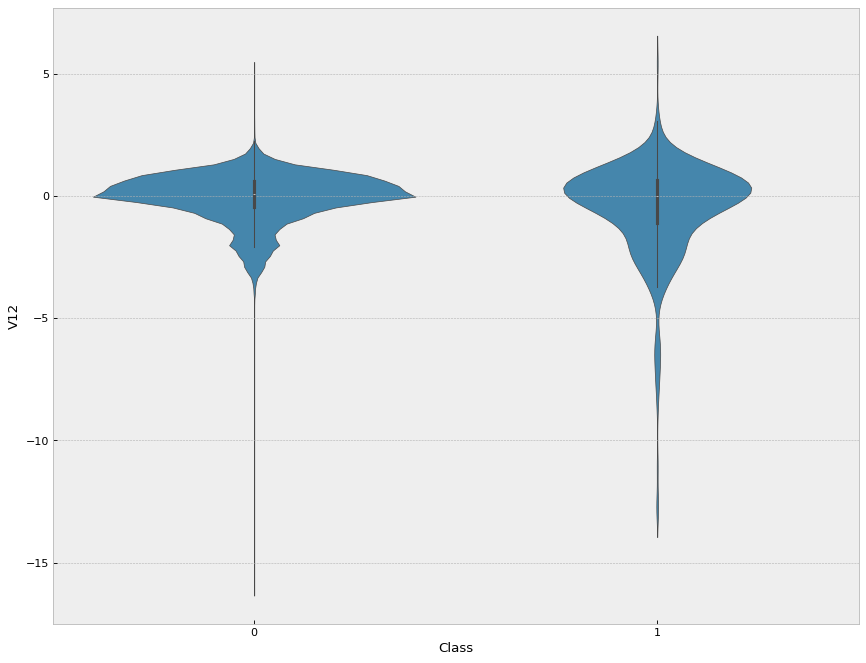

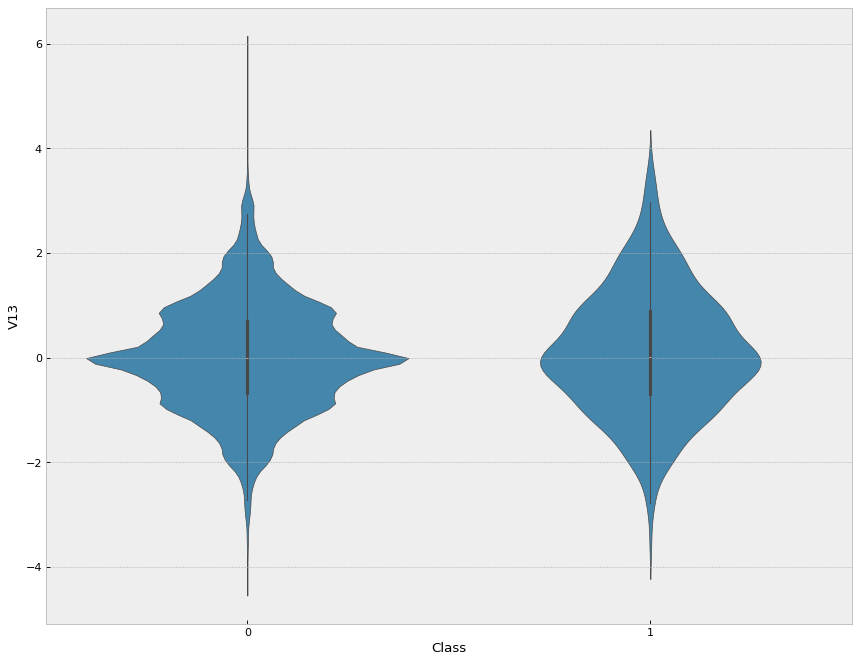

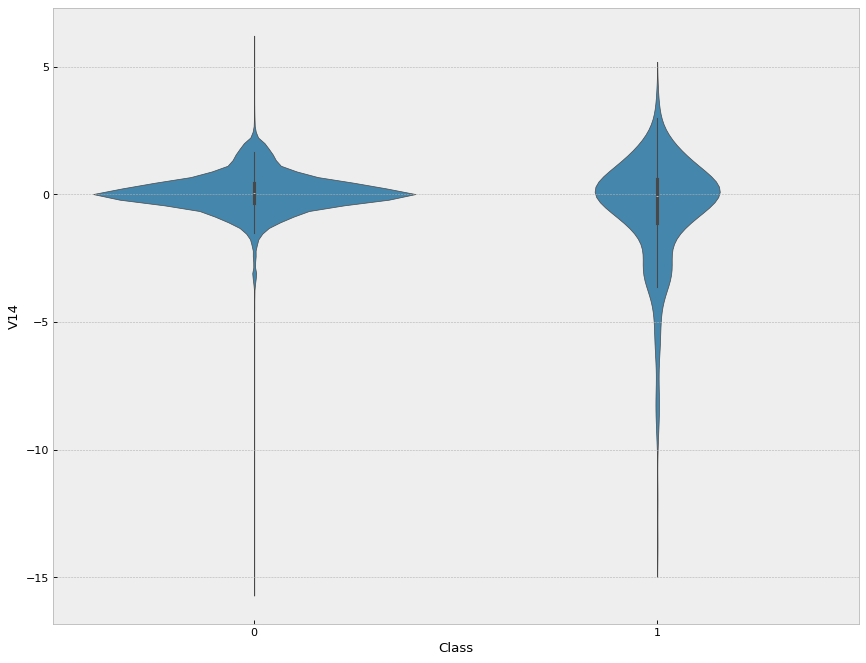

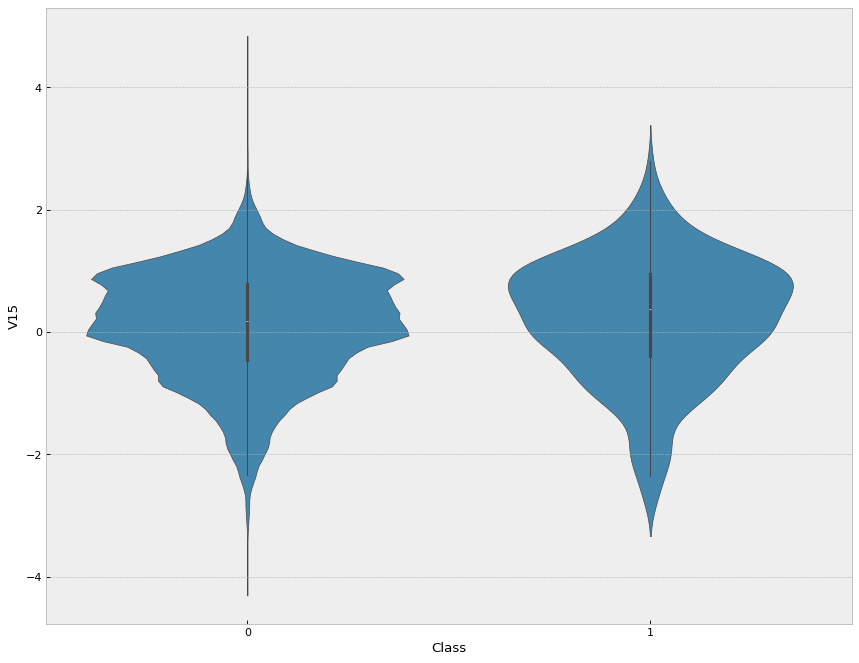

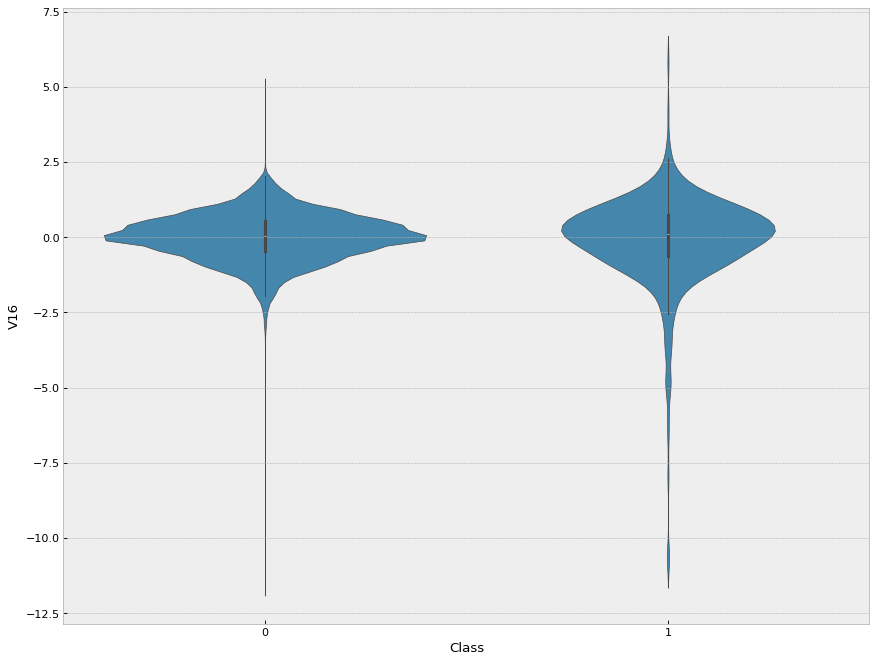

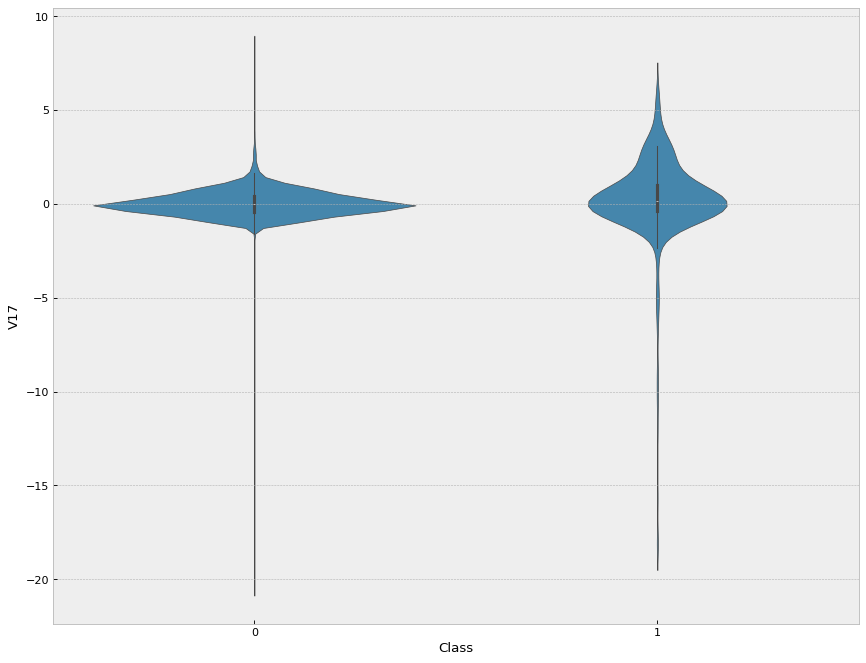

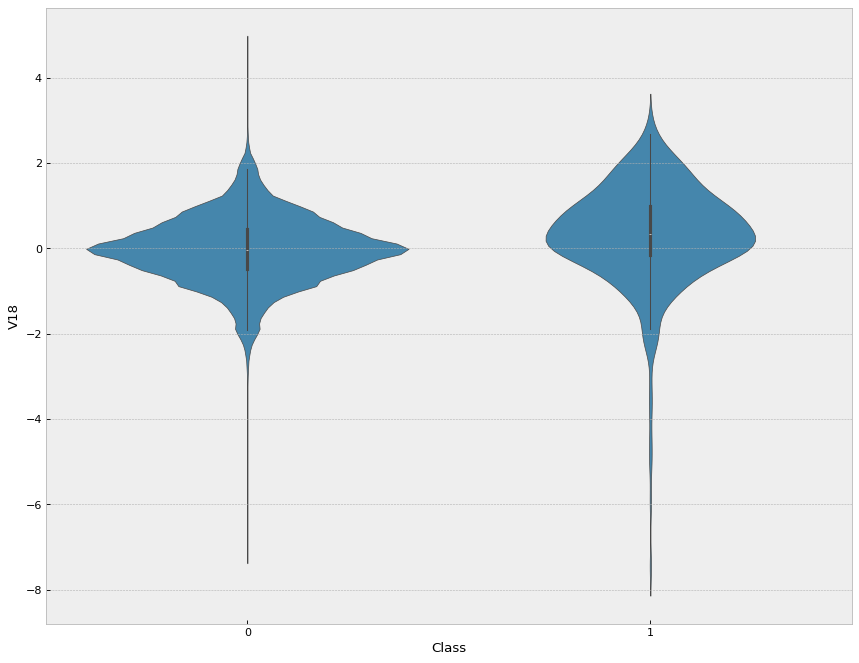

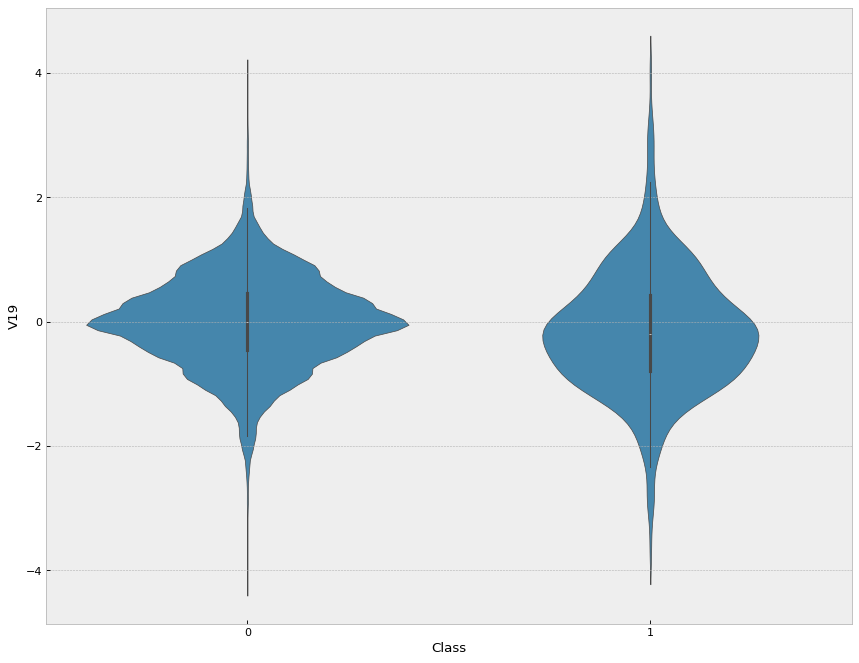

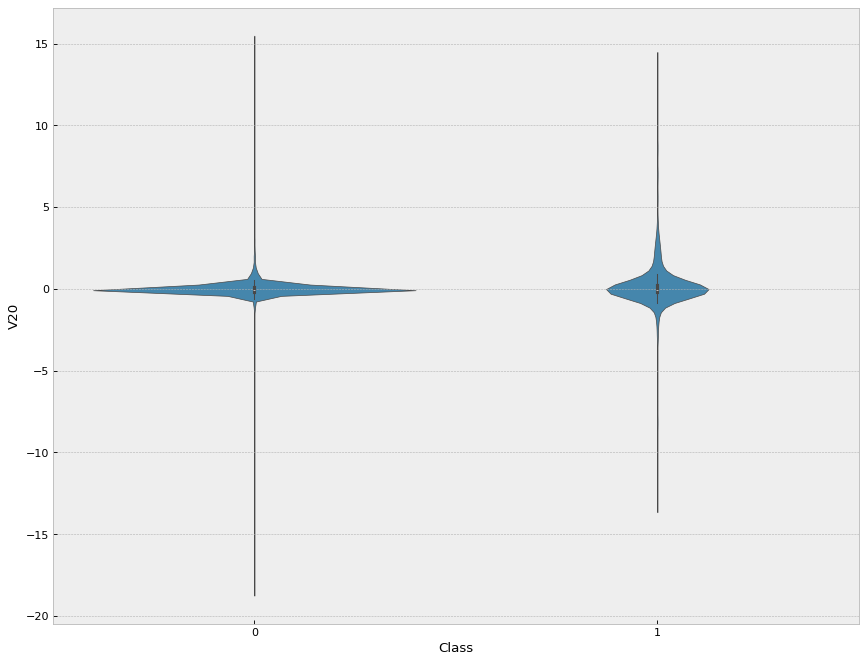

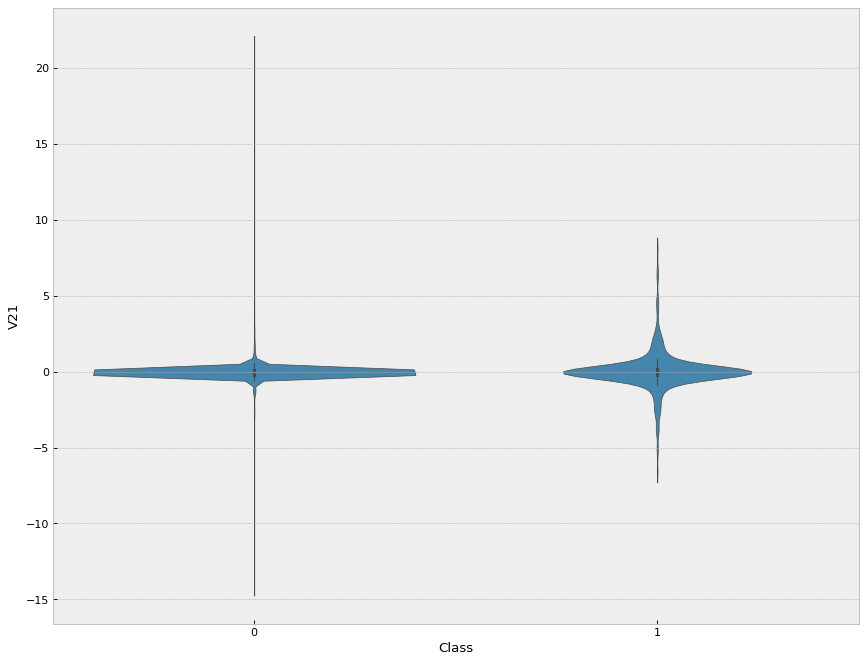

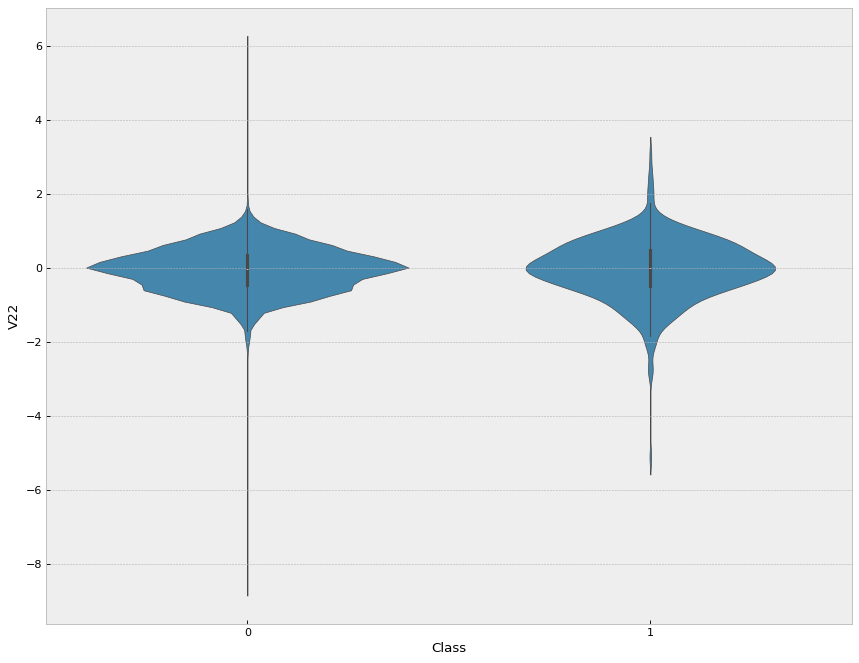

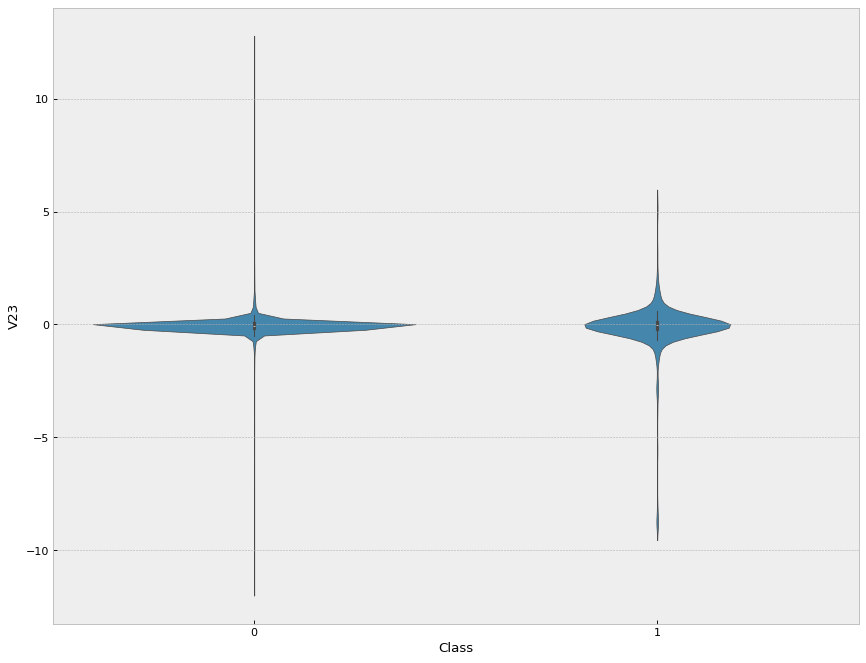

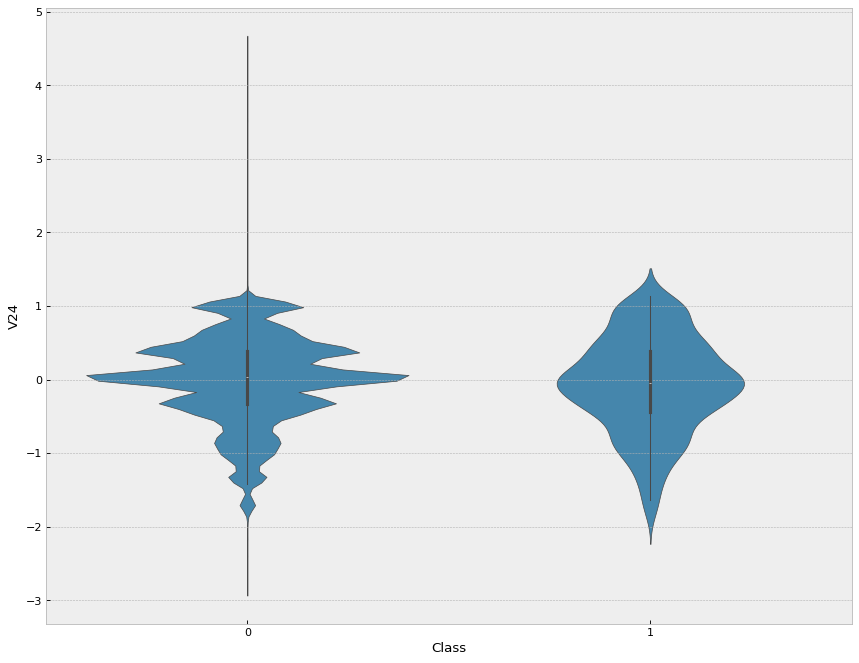

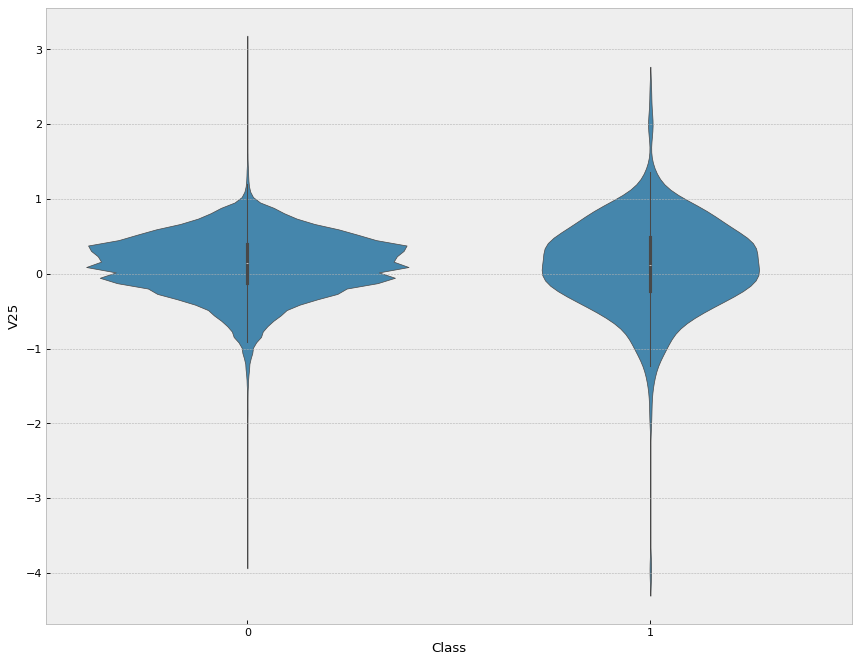

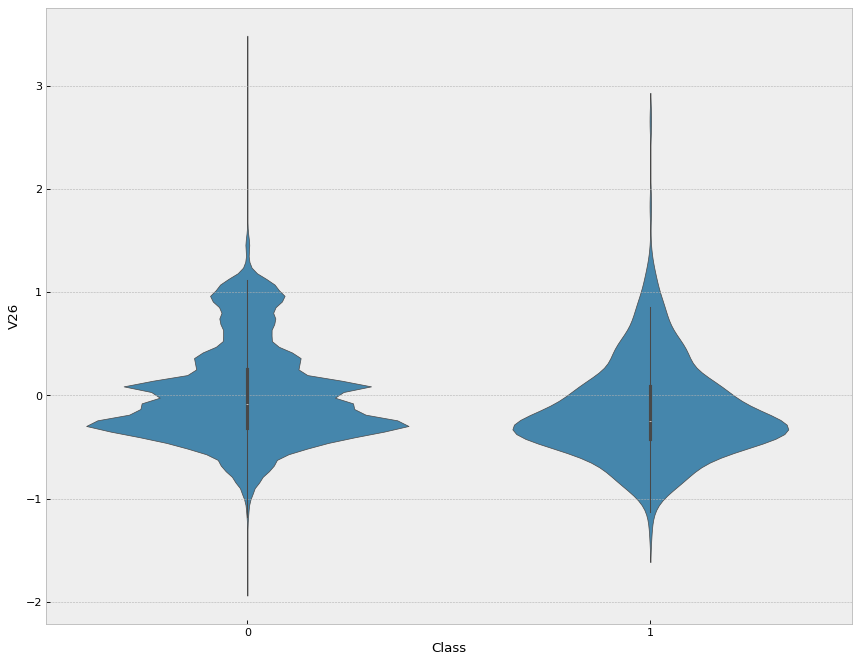

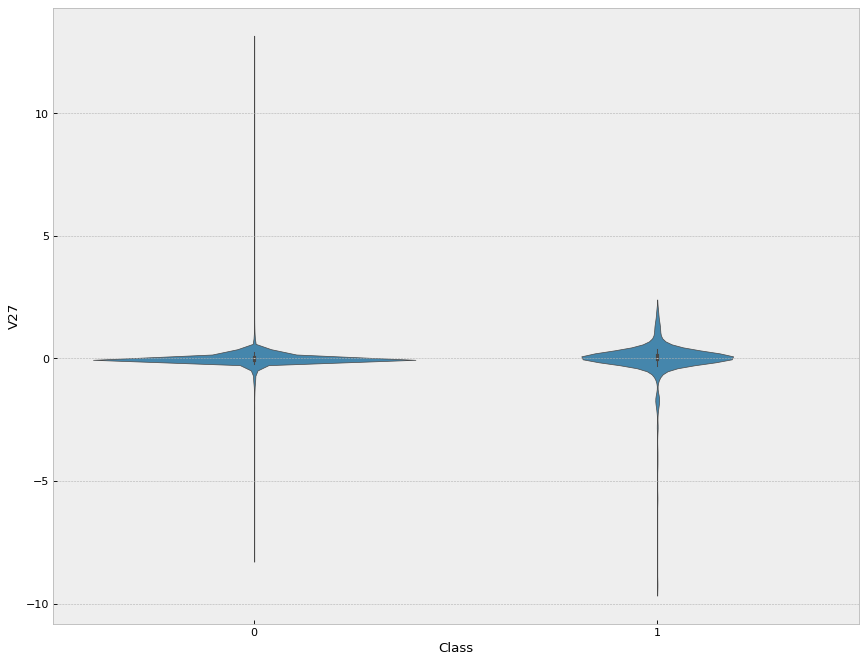

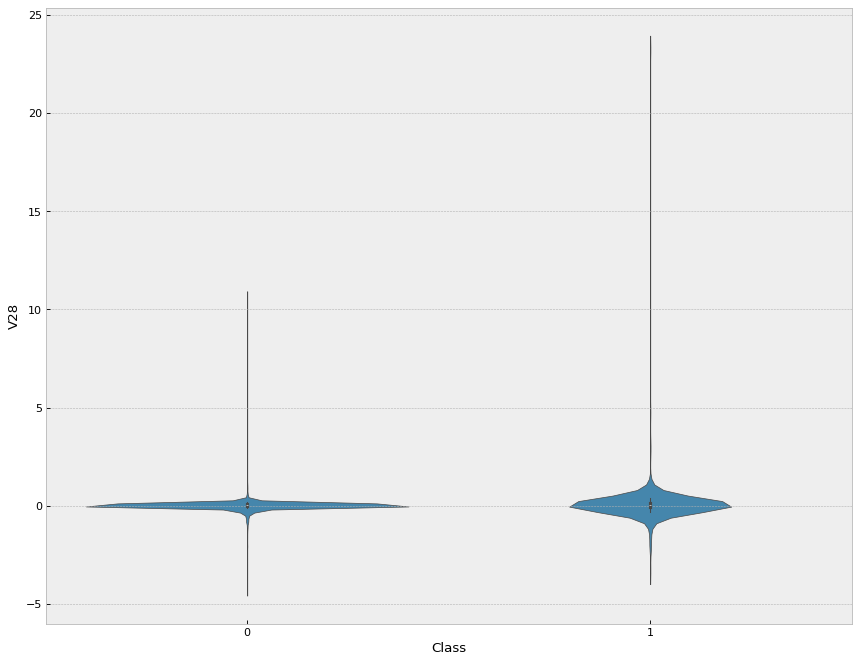

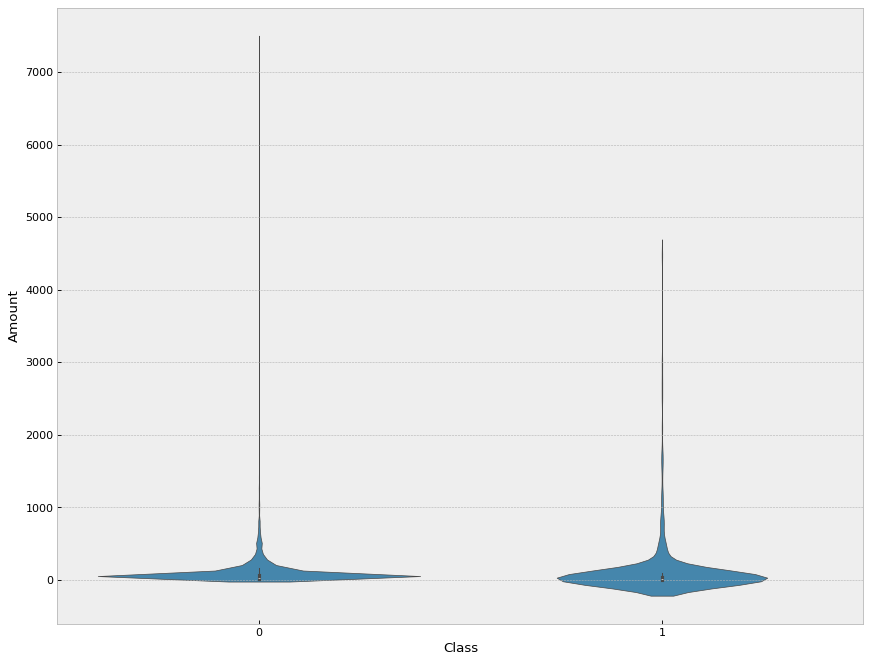

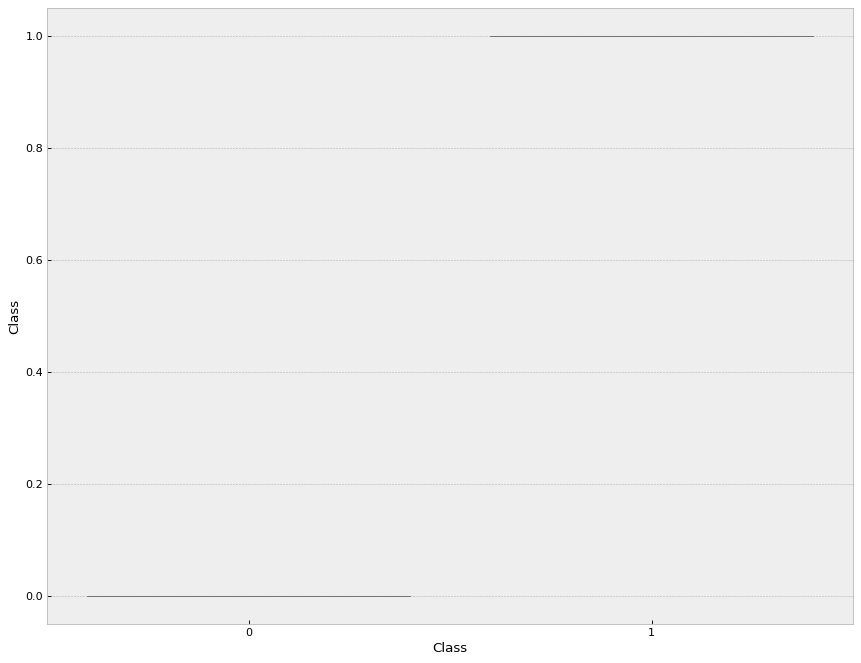

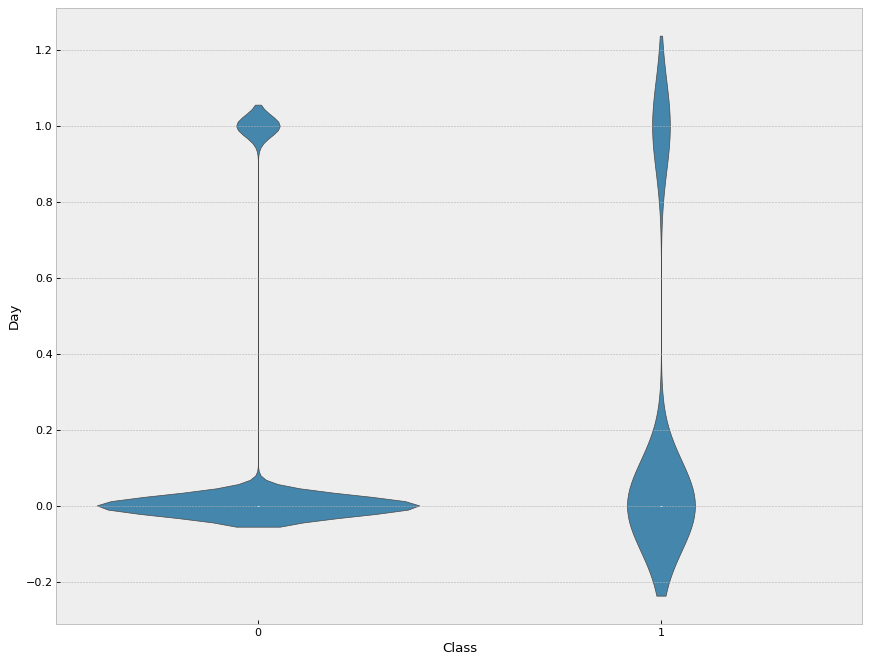

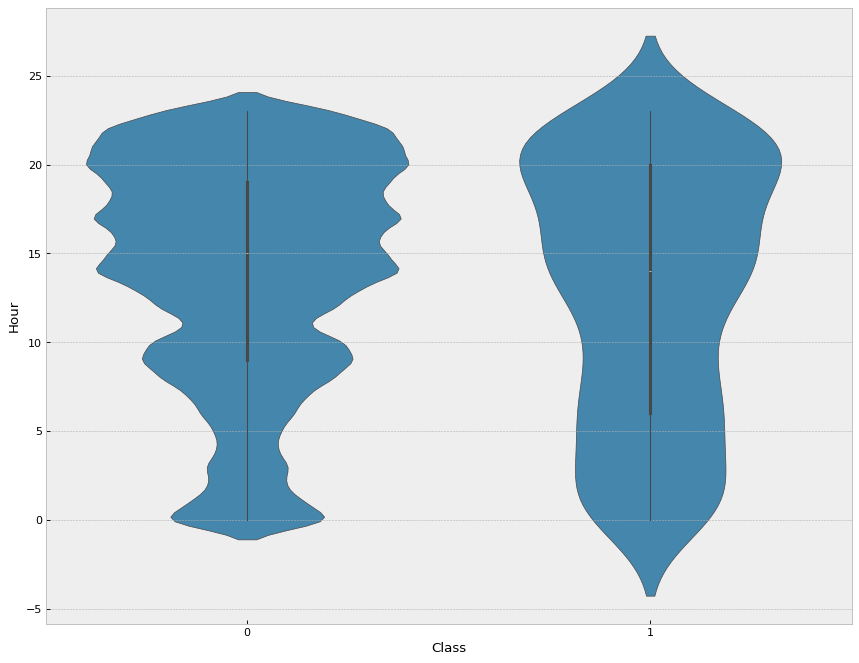

In [17]:
for col in data_eda.columns:
    plt.figure(figsize=(13,10), dpi= 80)
    sns.violinplot(x='Class', y=col, data=data_eda)
    plt.show()

In [18]:
# As per some features I found that there are differences between medians. I will use it as new features

In [19]:
# Create a list of columns where is significant difference of median and standard deviation of normal and fraud data

difference = fraud.describe()-normal.describe()

print('Medians differences')
print(difference.loc['50%'][np.abs(difference.loc['50%']) > 0.17])
print()

print('Standard deviations differences')
print(difference.loc['std'][np.abs(difference.loc['std']) > 1.2])


dif_columns = list(set(difference.loc['50%'][np.abs(difference.loc['50%']) > 0.17].index) \
              | set(difference.loc['std'][np.abs(difference.loc['std']) > 1.2].index))
dif_columns.remove('Class')

print()
dif_columns.sort()
print(dif_columns)

Medians differences
V1        -0.989988
V2         0.542936
V3        -0.988509
V4         0.747846
V5         0.245809
V7        -0.170501
V10       -0.264117
V11        0.329867
V15        0.193899
V18        0.371271
V19       -0.199866
Amount   -13.140000
Class      1.000000
Hour      -1.000000
Name: 50%, dtype: float64

Standard deviations differences
V1          1.815018
V2          3.111524
V3          1.634318
V7          1.656029
V8          1.689561
V10         1.422745
V14         1.382012
V17         1.708173
Amount    226.667878
Name: std, dtype: float64

['Amount', 'Hour', 'V1', 'V10', 'V11', 'V14', 'V15', 'V17', 'V18', 'V19', 'V2', 'V3', 'V4', 'V5', 'V7', 'V8']


# Data

In [7]:
data = pd.read_csv(file, index_col = 'id')
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,0.742144,0.108782,-1.070243,-0.234910,-1.099360,0.502467,0.169318,0.065688,-0.306957,-0.323800,0.103348,-0.292969,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,-0.109948,0.908773,0.836798,-0.056580,-0.120990,-0.144028,-0.039582,1.653057,-0.253599,-0.814354,0.716784,0.065717,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,-0.042027,-0.818383,-0.376512,-0.226546,-0.552869,-0.886466,-0.180890,0.230286,0.590579,-0.321590,-0.433959,-0.021375,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,0.885838,-0.007527,0.637441,0.676960,-1.504823,0.554039,-0.824356,-0.527267,-0.095838,-0.312519,0.642659,-0.340089,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,0.692665,-0.097495,1.338869,1.391399,-0.128167,-0.081836,0.100548,-0.338937,0.090864,-0.423645,-0.731939,-0.203628,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219124,120580.0,1.891079,-1.272908,-3.783908,-1.388939,2.012789,2.666080,0.151740,0.401934,-1.102824,0.858158,-0.280639,0.007976,-0.124950,0.914374,-0.073169,-2.309929,-0.041423,1.190526,-0.281848,-0.195703,-0.181369,-0.456538,-0.069571,0.756765,0.244479,-0.147566,-0.054725,-0.044588,198.65,0
219125,120580.0,0.139724,0.948649,-2.913655,-2.184829,1.883716,-1.056824,1.725624,0.018089,-0.823494,-0.257933,-0.457534,0.516146,-0.071240,1.310799,-1.892909,-0.318780,-0.917395,0.098397,-0.195558,-0.116538,0.491469,1.478823,-0.085398,-0.091409,-1.053488,0.467570,0.358918,0.294735,24.00,0
219126,120580.0,2.058343,-0.038993,-1.928553,0.330117,0.270127,-0.735664,-0.173878,0.144823,0.849289,-0.136498,0.179926,-1.769641,-3.937694,0.031346,0.028100,0.883566,0.391801,1.007789,0.303376,-0.384830,-0.306640,-0.965783,0.307799,-0.021434,-0.343989,0.181065,-0.098387,-0.044064,1.79,0


Create a Data Transformer that transforms Time to Day and Hour. Hour is a categorical feature, so I will use TargetEncoder to encode it. 

During EDA, I discovered a difference between the medians of the target classes. I will generate new features as the deviation from the medians. 

After all other transformations I use StandardScaler 

In [8]:
class DataTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.TargetEncoder = TargetEncoder(smooth = 0, cv = 5, random_state = 42)

    def fit(self, X, y):
      
        X_copy = X.copy()

        #60*60*24 = 86400 seconds in a day
        next_day_idx = X_copy[X_copy['Time'] > 86400-1].index  #indexes of transaction on the 2nd day 
        X_copy.loc[next_day_idx, 'Time'] -= 86400 
        X_copy['Hour'] = X_copy['Time'] // 3600

        self.TargetEncoder.fit(X_copy[['Hour']], y)
        
        feature_columns = ['Amount','V1', 'V10', 'V11', 'V14', 'V15', 'V17', 'V18', 'V19', 'V2', 'V3', 'V4', 'V5', 'V7', 'V8']
        self.median_dict = {}

        normal_idx = y[y == 0].index # save the values of medians for new feature columns
        for col in feature_columns:
            self.median_dict[col] = X_copy.loc[normal_idx, col].median()
        
        return self

    def transform(self, X, y = None):
        
        self.X = X.copy()

        for col in self.median_dict.keys():
            
            self.X[f'dev_{col}'] = (self.X[col] - self.median_dict[col])**2

        #60*60*24 = 86400 seconds in the a day
        next_day_idx = self.X[self.X['Time'] > 86400-1].index #indexes of transaction on the 2nd day 
        self.X['Day'] = np.zeros(self.X.shape[0])
        self.X.loc[next_day_idx, 'Day'] = 1
        self.X.loc[next_day_idx, 'Time'] -= 86400 
        
        self.X['Hour'] = self.X['Time'] // 3600
        self.X['Hour'] = self.TargetEncoder.transform(self.X[['Hour']])
        self.X = self.X.drop('Time', axis = 1)

        return self.X



preprocesser = Pipeline([('DataTransformer', DataTransformer()),
                         ('scaler', StandardScaler())
                        ])

# DataSplit

In the data there is only 1.5 days and I will encode Hour as categorical feature so I will not use Stratified K-Fold, just basic one 

In [9]:
X = data.drop('Class', axis = 1)
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25, 
                                                    shuffle = True, 
                                                    random_state = 42)

In [10]:
splitter = KFold(n_splits = 4, shuffle = True, random_state = 42)

# Logistic Regression

Training Linear Regression model. The strength of the model is the ability to correctly estimate the probability of class membership. I use 'saga' solver because it is able to work with l1 and l2 regularization. Also I set class weights because  the classes are very imbalanced.

In [24]:
pipe_lr = Pipeline([('transformer', preprocesser),
                    ('lr', LogisticRegression(penalty = 'l1', 
                                              C = 0.0005,
                                              class_weight = {0:1, 1:200}, 
                                              max_iter = 600,
                                              tol = 1e-2,
                                              solver = 'saga',
                                              n_jobs = -1))])

In [25]:
%%time
pipe_lr.fit(X_train, y_train)

CPU times: user 4.27 s, sys: 72.3 ms, total: 4.34 s
Wall time: 4.25 s


Pipeline(steps=[('transformer',
                 Pipeline(steps=[('DataTransformer', DataTransformer()),
                                 ('scaler', StandardScaler())])),
                ('lr',
                 LogisticRegression(C=0.0005, class_weight={0: 1, 1: 200},
                                    max_iter=600, n_jobs=-1, penalty='l1',
                                    solver='saga', tol=0.01))])

Drawing ROC-curves on test and train samples. The ROC-AUC are very similar, so there is no overfitting.

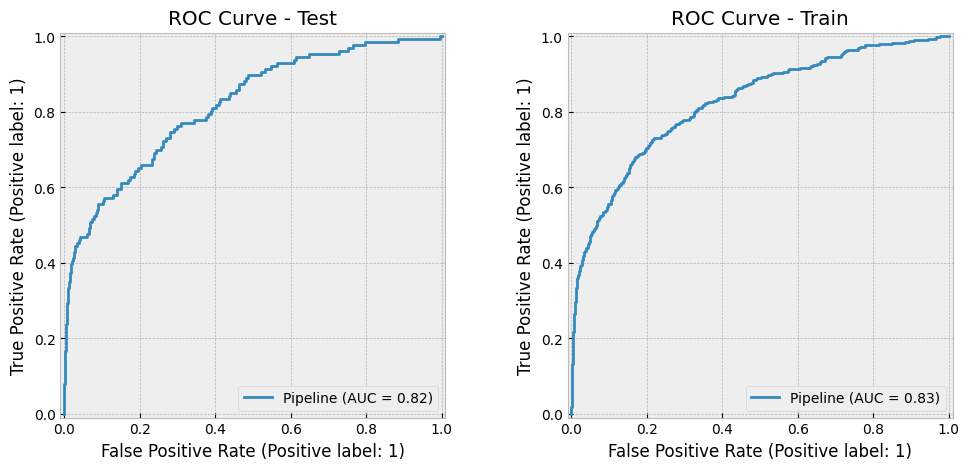

In [26]:
lr_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(pipe_lr, X_test, y_test, ax=ax[0])
ax[0].set_title("ROC Curve - Test")

display_train = RocCurveDisplay.from_estimator(pipe_lr, X_train, y_train, ax=ax[1])
ax[1].set_title("ROC Curve - Train")

plt.show()

In [27]:
fpr_lr, tpr_lr, t = roc_curve(y_test, pipe_lr.predict_proba(X_test)[:,1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

print('ROC-AUC score of Linear Regression on test:', round(roc_auc_lr, 3))

ROC-AUC score of Linear Regression on test: 0.818


Searching for the best parameters

In [28]:
param_grid_lr = {'lr__penalty': ['l2', 'l1'],
                 'lr__C': [0.0005, 0.005, 0.01, 0.05, 0.1],
                 'lr__class_weight': [{0:1, 1:50}, {0:1, 1:100}, {0:1, 1:150}, {0:1, 1:250}, {0:1, 1:350}]}

search_lr = GridSearchCV(estimator = pipe_lr,
                         param_grid = param_grid_lr,
                         scoring = 'roc_auc',
                         cv = splitter,
                         n_jobs = -1,
                         verbose = 10)

In [29]:
%%time
search_lr.fit(X_train, y_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits
CPU times: user 9.6 s, sys: 2.42 s, total: 12 s
Wall time: 20min 43s


GridSearchCV(cv=KFold(n_splits=4, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        Pipeline(steps=[('DataTransformer',
                                                         DataTransformer()),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('lr',
                                        LogisticRegression(C=0.0005,
                                                           class_weight={0: 1,
                                                                         1: 200},
                                                           max_iter=600,
                                                           n_jobs=-1,
                                                           penalty='l1',
                                                           solver='saga',
                                                           tol=0.01))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.0005, 0.005, 0.01, 0.05, 0.1],
                         'lr__class_weight': [{0: 1, 1: 50}, {0: 1, 1: 100},
                                              {0: 1, 1: 150}, {0: 1, 1: 250},
                                              {0: 1, 1: 350}],
                         'lr__penalty': ['l2', 'l1']},
             scoring='roc_auc', verbose=10)

In [30]:
search_lr.best_score_

0.8037210322071262

In [31]:
search_lr.best_params_

{'lr__C': 0.0005, 'lr__class_weight': {0: 1, 1: 150}, 'lr__penalty': 'l1'}

Plotting the learning curves

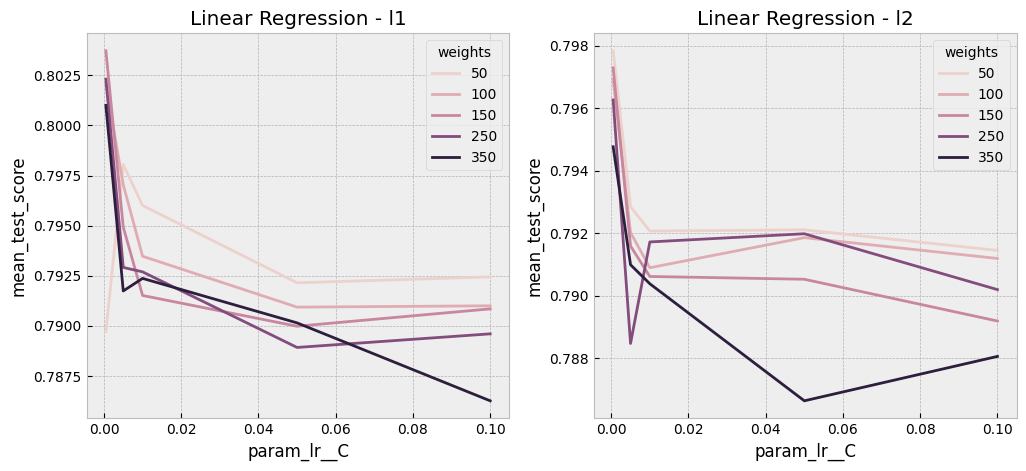

In [32]:
lr_cv_params = pd.DataFrame(search_lr.cv_results_)
lr_cv_params['weights'] = lr_cv_params['param_lr__class_weight'].apply(lambda x: x[1])

lr_cv_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i, j in enumerate(np.sort(lr_cv_params['param_lr__penalty'].unique())):

    sns.lineplot(data = lr_cv_params[lr_cv_params['param_lr__penalty'] == j],
                 ax=ax[i],
                 x = 'param_lr__C',
                 y = 'mean_test_score',
                 hue = 'weights')
    ax[i].set_title(f"Linear Regression - {j}")

plt.show()

# SVM

Training SVM. SVM basicly can't correctly estimate the probability of class membership. It requires calibration. I use 'squared_hinge' loss because The combination of penalty='l1' and loss='hinge' is not supported. I also set class_weight, because the problem of imbalanced classes.

In [33]:
pipe_svm = Pipeline([('transformer', preprocesser),
                     ('svm', LinearSVC(penalty = 'l1', 
                                       dual = 'auto',
                                       class_weight = {0: 1, 1: 150}, 
                                       loss = 'squared_hinge',
                                       C = 0.001,
                                       max_iter = 1300,
                                       tol = 1e-4))])

In [34]:
%%time
pipe_svm.fit(X_train, y_train)

CPU times: user 9.55 s, sys: 215 ms, total: 9.76 s
Wall time: 9.7 s


Pipeline(steps=[('transformer',
                 Pipeline(steps=[('DataTransformer', DataTransformer()),
                                 ('scaler', StandardScaler())])),
                ('svm',
                 LinearSVC(C=0.001, class_weight={0: 1, 1: 150}, max_iter=1300,
                           penalty='l1'))])

Drawing ROC-curves on test and train samples. The ROC-AUC are very similar, so there is no overfitting.

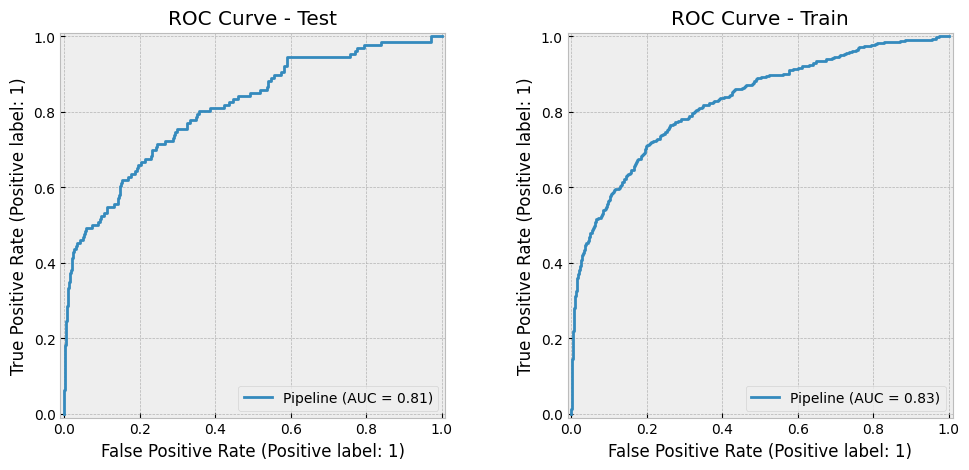

In [35]:
svm_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(pipe_svm, X_test, y_test, ax=ax[0])
ax[0].set_title("ROC Curve - Test")

display_train = RocCurveDisplay.from_estimator(pipe_svm, X_train, y_train, ax=ax[1])
ax[1].set_title("ROC Curve - Train")

plt.show()

In [36]:
fpr_svm, tpr_svm, t = roc_curve(y_test, pipe_svm.decision_function(X_test))
roc_auc_svm = auc(fpr_svm, tpr_svm)

print('ROC-AUC score of SVM on test:', round(roc_auc_svm, 3))

ROC-AUC score of SVM on test: 0.81


Searching for the best parameters

In [37]:
param_grid_svm = {'svm__penalty': ['l2', 'l1'],
                  'svm__C': [0.001, 0.005, 0.01, 0.05, 0.1],
                  'svm__class_weight': [{0:1, 1:200}, {0:1, 1:150}, {0:1, 1:300}, {0:1, 1:250}]}

search_svm = GridSearchCV(estimator = pipe_svm,
                          param_grid = param_grid_svm,
                          scoring = 'roc_auc',
                          cv = splitter,
                          n_jobs = -1,
                          verbose = 10)

In [38]:
%%time
search_svm.fit(X_train, y_train)

Fitting 4 folds for each of 40 candidates, totalling 160 fits
CPU times: user 11.7 s, sys: 1.48 s, total: 13.1 s
Wall time: 6min 28s


GridSearchCV(cv=KFold(n_splits=4, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        Pipeline(steps=[('DataTransformer',
                                                         DataTransformer()),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('svm',
                                        LinearSVC(C=0.001,
                                                  class_weight={0: 1, 1: 150},
                                                  max_iter=1300,
                                                  penalty='l1'))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.001, 0.005, 0.01, 0.05, 0.1],
                         'svm__class_weight': [{0: 1, 1: 200}, {0: 1, 1: 150},
                                               {0: 1, 1: 300}, {0: 1, 1: 250}],
                         'svm__penalty': ['l2', 'l1']},
             scoring='roc_auc', verbose=10)

In [39]:
print('Score on CV:', search_svm.best_score_)
print('Best params:', search_svm.best_params_)

Score on CV: 0.7882141097636839
Best params: {'svm__C': 0.001, 'svm__class_weight': {0: 1, 1: 150}, 'svm__penalty': 'l1'}


Plotting the learning curves

In [ ]:
svm_cv_params = pd.DataFrame(search_svm.cv_results_)
svm_cv_params['weights'] = svm_cv_params['param_svm__class_weight'].apply(lambda x: x[1])

svm_cv_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data = svm_cv_params[svm_cv_params['param_svm__penalty'] == 'l1'],
             ax=ax[0],
             x = 'param_svm__C',
             y = 'mean_test_score',
             hue = 'weights')
ax[0].set_title("SVM - l1")

sns.lineplot(data = svm_cv_params[svm_cv_params['param_svm__penalty'] == 'l2'],
             ax=ax[1],
             x = 'param_svm__C',
             y = 'mean_test_score',
             hue = 'weights')
ax[1].set_title("SVM - l2")


plt.show()

As I said earlier, SVM is not able to estimate the probability of class membership correctly - it requires a calibration. The calibration will be applied as per Platt’s method (sigmoid function).

Plotting calibration curve (perfectly calibrated model will be shown as a diagonal line)

Uncalibrated SVM model is shown as a horizontal line with an angle

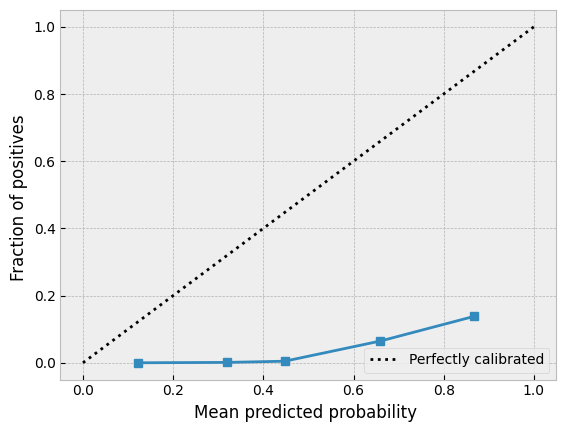

In [42]:
def sigmoid(array):
    return 1 / (1 + np.exp(-array))
    
svm_proba = sigmoid(pipe_svm.decision_function(X_test))

prob_true_svm, prob_pred_svm = calibration_curve(y_test,
                                                 svm_proba,
                                                 n_bins=5)

CalibrationDisplay(prob_true = prob_true_svm, 
				   prob_pred = prob_pred_svm, 
				   y_prob = svm_proba).plot()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

#create calibrator
plats_calibration = CalibratedClassifierCV(pipe_svm,
										   n_jobs = -1,
                                           cv=3,
                                           method='sigmoid',
                                           ensemble = True)


plats_calibration.fit(X_train, y_train)

# getting calibrated probabilities of positive class membership
calibrated_proba = plats_calibration.predict_proba(X_test)[:, 1]


prob_true_svm, prob_pred_svm = calibration_curve(y_test,
                                                 calibrated_proba, # new
                                                 n_bins=5)

CalibrationDisplay(prob_true = prob_true_svm, 
				   prob_pred = prob_pred_svm, 
				   y_prob = calibrated_proba).plot() # new

# Decision Tree

Decision Trees are very powerful models, so they prone to overfitting (they shows 100% train score, but very low test score). The main task when training Decision Trees is a counter overfitting (fit the rigth regularization). 

There are several ways to counter overfitting:
* to set the max length of the tree (so it will divide up only to a certain number, and so it will ignore outliers and specific facilities
* to set minimum quantity of samples in a leaf (it will devide up while number of samples in leaf is bigger than the threshold, so will not be able to fit to outliers and specific facilities, becuse usualy it requires much less quantity of samples in a leaf)
* to set minimum quantity of smaples in split
* to set minumum weigh of class in leaf (it will not devide if there is alredy domination of one class over another in a leaf)
* to set maximum quantity of leafs
* and to set minumum quality increase

I will use the 1st and the 2nd one.

In [44]:
pipe_tree = Pipeline([('transformer', preprocesser),
                      ('decision_tree', DecisionTreeClassifier(random_state = 42,
                                                               max_depth = 20,
                                                               min_samples_leaf = 4000,
                                                               class_weight = {0: 1, 1: 50}))])

In [45]:
%%time
pipe_tree.fit(X_train, y_train)

CPU times: user 13 s, sys: 31 ms, total: 13 s
Wall time: 13 s


Pipeline(steps=[('transformer',
                 Pipeline(steps=[('DataTransformer', DataTransformer()),
                                 ('scaler', StandardScaler())])),
                ('decision_tree',
                 DecisionTreeClassifier(class_weight={0: 1, 1: 50},
                                        max_depth=20, min_samples_leaf=4000,
                                        random_state=42))])

Drawing ROC-curves on test and train samples. The ROC-AUC on train is not 1.00 (overfitted model with default settings), but on test it is much lower (0.74 vs 0.86). I will also plot the learning curves on CV during searching best parametres.

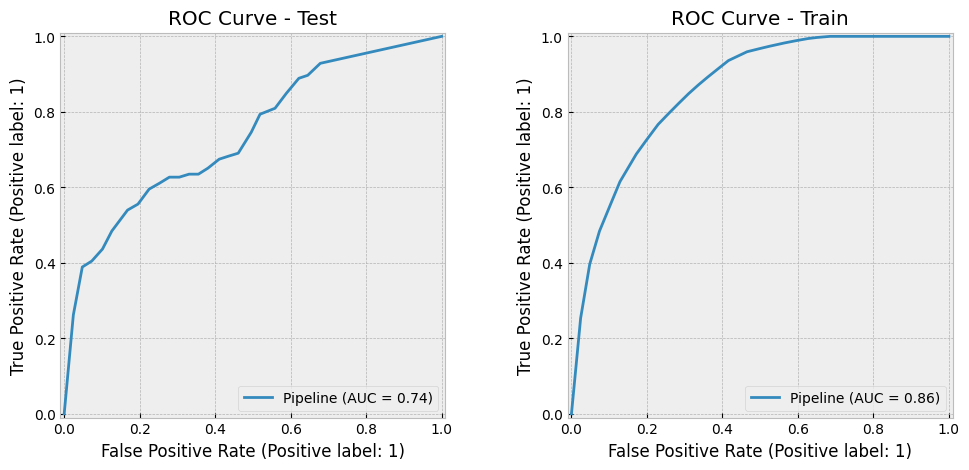

In [46]:
tree_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(pipe_tree, X_test, y_test, ax=ax[0])
ax[0].set_title("ROC Curve - Test")

display_train = RocCurveDisplay.from_estimator(pipe_tree, X_train, y_train, ax=ax[1])
ax[1].set_title("ROC Curve - Train")

plt.show()

In [47]:
fpr_tree, tpr_tree, t = roc_curve(y_test, pipe_tree.predict_proba(X_test)[:,1])
roc_auc_tree = auc(fpr_tree, tpr_tree)

print('ROC-AUC score of Decision Tree on test:', round(roc_auc_tree, 3))

ROC-AUC score of Decision Tree on test: 0.739


Searching for the best parameters

In [48]:
param_grid_tree = {'decision_tree__max_depth': [20, 35, 45], 
                   'decision_tree__min_samples_leaf': [2, 30, 100, 300, 800, 1500, 2500, 4000, 8000, 20000],
                   'decision_tree__class_weight': [{0:1, 1:30}, {0:1, 1:50}, {0:1, 1:75}, {0:1, 1:100}]} 

search_tree = GridSearchCV(estimator = pipe_tree,
                           param_grid = param_grid_tree,
                           scoring = 'roc_auc',
                           cv = splitter,
                           n_jobs = -1,
                           verbose = 10)

In [49]:
%%time
search_tree.fit(X_train, y_train)

Fitting 4 folds for each of 120 candidates, totalling 480 fits
CPU times: user 21.7 s, sys: 4.35 s, total: 26.1 s
Wall time: 30min 25s


GridSearchCV(cv=KFold(n_splits=4, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        Pipeline(steps=[('DataTransformer',
                                                         DataTransformer()),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('decision_tree',
                                        DecisionTreeClassifier(class_weight={0: 1,
                                                                             1: 50},
                                                               max_depth=20,
                                                               min_samples_leaf=4000,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'decision_tree__class_weight': [{0: 1, 1: 30},
                                                         {0: 1, 1: 50},
                                                         {0: 1, 1: 75},
                                                         {0: 1, 1: 100}],
                         'decision_tree__max_depth': [20, 35, 45],
                         'decision_tree__min_samples_leaf': [2, 30, 100, 300,
                                                             800, 1500, 2500,
                                                             4000, 8000,
                                                             20000]},
             scoring='roc_auc', verbose=10)

In [50]:
print('Score on CV:', search_tree.best_score_)
print('Best params:', search_tree.best_params_)

Score on CV: 0.7577749224321781
Best params: {'decision_tree__class_weight': {0: 1, 1: 50}, 'decision_tree__max_depth': 20, 'decision_tree__min_samples_leaf': 4000}


Plotting the learning curves (after 5000 leafs scores monotonically decrease, so I limited x values)

In [ ]:
tree_cv_params = pd.DataFrame(search_tree.cv_results_)
tree_cv_params['weights'] = tree_cv_params['param_decision_tree__class_weight'].apply(lambda x: x[1])

tree_cv_fig, ax = plt.subplots(1, 3, figsize=(12, 5))

for i, j in enumerate(tree_cv_params['param_decision_tree__max_depth'].unique()):

    sns.lineplot(data = tree_cv_params[tree_cv_params['param_decision_tree__max_depth'] == j],
                 ax=ax[i],
                 x = 'param_decision_tree__min_samples_leaf',
                 y = 'mean_test_score',
                 hue = 'weights')
    ax[i].set_title(f"Decision tree - depth {j}")
    ax[i].set_xlim(-100, 5000)
    ax[i].set_xlabel('min_samples_leaf')

plt.show()

In [ ]:
tree_cv_fig_1, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(data = tree_cv_params[tree_cv_params['param_decision_tree__min_samples_leaf'] == 1500],
             ax=ax[0],
             x = 'weights',
             y = 'mean_test_score',
             hue = 'param_decision_tree__max_depth')
ax[0].set_title("Decision tree - 1500 leafs")
ax[0].set_ylim(0.7, 0.76)

sns.lineplot(data = tree_cv_params[tree_cv_params['param_decision_tree__min_samples_leaf'] == 4000],
             ax=ax[1],
             x = 'weights',
             y = 'mean_test_score',
             hue = 'param_decision_tree__max_depth')
ax[1].set_title("Decision tree - 4000 leafs")
ax[1].set_ylim(0.7, 0.76)

plt.show()

# RandomForest

Random Forest is a special case of bagging ensemble (training some amount of models using Bootstrap Aggregetion), that uses Decision Trees as a base model. 

In [12]:
pipe_forest = Pipeline([('transformer', preprocesser),
						('forest', RandomForestClassifier(n_jobs = -1,
                                                          n_estimators = 80,
                                                          max_depth = 20,
                                                          min_samples_leaf = 350,
                                                          class_weight = {0: 1, 1: 50}))])

In [54]:
%%time
pipe_forest.fit(X_train, y_train)

CPU times: user 2min 38s, sys: 41.3 ms, total: 2min 38s
Wall time: 40.9 s


Pipeline(steps=[('transformer',
                 Pipeline(steps=[('DataTransformer', DataTransformer()),
                                 ('scaler', StandardScaler())])),
                ('forest',
                 RandomForestClassifier(class_weight={0: 1, 1: 50},
                                        max_depth=20, min_samples_leaf=350,
                                        n_estimators=80, n_jobs=-1))])

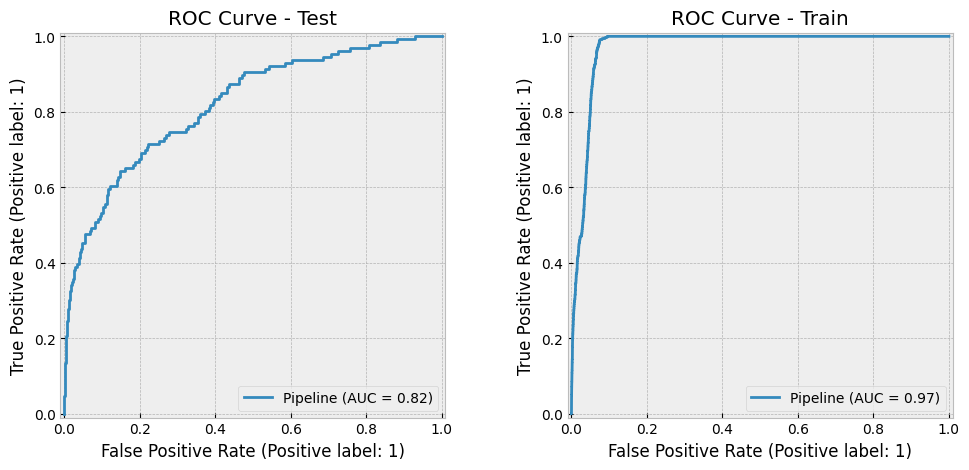

In [55]:
forest_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(pipe_forest, X_test, y_test, ax=ax[0])
ax[0].set_title("ROC Curve - Test")

display_train = RocCurveDisplay.from_estimator(pipe_forest, X_train, y_train, ax=ax[1])
ax[1].set_title("ROC Curve - Train")

plt.show()

In [56]:
fpr_forest, tpr_forest, t = roc_curve(y_test, pipe_forest.predict_proba(X_test)[:,1])
roc_auc_forest = auc(fpr_forest, tpr_forest)

print('ROC-AUC score of Random Forest on test:', round(roc_auc_forest, 3))

ROC-AUC score of Random Forest on test: 0.82


In [13]:
param_grid_forest = {'forest__n_estimators': [80, 150], 
                     'forest__class_weight': [{0: 1, 1: 50}, {0: 1, 1: 75}],
                     'forest__max_depth': [20, 30],
                     'forest__min_samples_leaf': [20, 100, 350, 1000]}

search_forest = GridSearchCV(estimator = pipe_forest,
                           param_grid = param_grid_forest,
                           scoring = 'roc_auc',
                           cv = splitter,
                           n_jobs = -1,
                           verbose = 10)

In [14]:
%%time
search_forest.fit(X_train, y_train)

Fitting 4 folds for each of 32 candidates, totalling 128 fits
CPU times: user 7min 52s, sys: 10.7 s, total: 8min 3s
Wall time: 2h 17min 31s


GridSearchCV(cv=KFold(n_splits=4, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        Pipeline(steps=[('DataTransformer',
                                                         DataTransformer()),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('forest',
                                        RandomForestClassifier(class_weight={0: 1,
                                                                             1: 50},
                                                               max_depth=20,
                                                               min_samples_leaf=350,
                                                               n_estimators=80,
                                                               n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'forest__class_weight': [{0: 1, 1: 50}, {0: 1, 1: 75}],
                         'forest__max_depth': [20, 30],
                         'forest__min_samples_leaf': [20, 100, 350, 1000],
                         'forest__n_estimators': [80, 150]},
             scoring='roc_auc', verbose=10)

In [15]:
print('Score on CV:', search_forest.best_score_)
print('Best params:', search_forest.best_params_)

Score on CV: 0.8176569379591201
Best params: {'forest__class_weight': {0: 1, 1: 50}, 'forest__max_depth': 20, 'forest__min_samples_leaf': 350, 'forest__n_estimators': 150}


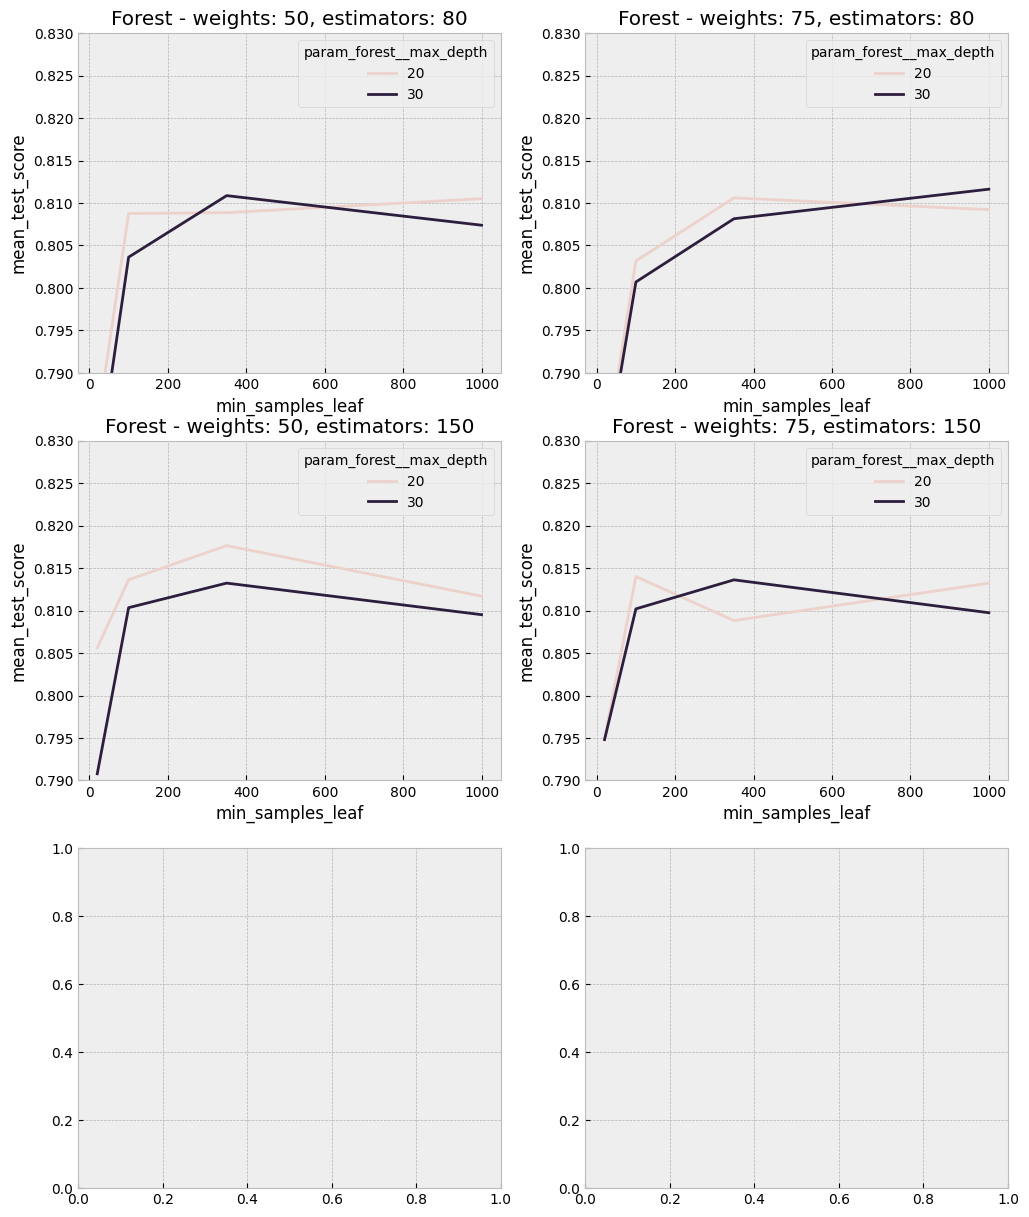

In [16]:
forest_cv_params = pd.DataFrame(search_forest.cv_results_)
forest_cv_params['weights'] = forest_cv_params['param_forest__class_weight'].apply(lambda x: x[1])

forest_cv_fig, ax = plt.subplots(3, 2, figsize=(12, 15))


for i, j in enumerate(np.sort(forest_cv_params['weights'].unique())):
    for s, m in enumerate(np.sort(forest_cv_params['param_forest__n_estimators'].unique())):
       
        sns.lineplot(data = forest_cv_params[(forest_cv_params['weights'] == j) & (forest_cv_params['param_forest__n_estimators'] == m)],
                     ax=ax[s, i],
                     x = 'param_forest__min_samples_leaf',
                     y = 'mean_test_score',
                     hue = 'param_forest__max_depth')
        ax[s, i].set_title(f"Forest - weights: {j}, estimators: {m}")
        ax[s, i].set_ylim(0.79, 0.83)
        ax[s, i].set_xlabel('min_samples_leaf')

In [ ]:
param_grid_forest_add = {'forest__n_estimators': [100], 
                         'forest__class_weight': [{0: 1, 1: 50}],
                         'forest__max_depth': [30, 35, 40],
                         'forest__min_samples_leaf': [1000, 1200, 1500, 2500]}

search_forest_add = GridSearchCV(estimator = pipe_forest,
                                 param_grid = param_grid_forest_add,
                                 scoring = 'roc_auc',
                                 cv = splitter,
                                 n_jobs = -1,
                                 verbose = 10)

In [ ]:
%%time
search_forest_add.fit(X_train, y_train)

In [ ]:
print('Score on CV:', search_forest_add.best_score_)
print('Best params:', search_forest_add.best_params_)

In [ ]:
forest_cv_params_add = pd.DataFrame(search_forest_add.cv_results_)

forest_cv_fig_add = plt.figure(figsize=(6, 5))
sns.lineplot(data = forest_cv_params_add,
             x = 'param_forest__min_samples_leaf',
             y = 'mean_test_score',
             hue = 'param_forest__max_depth')
plt.title(f"Forest - weights: {50}, estimators: {100}")
plt.ylim(0.79, 0.83)
plt.xlabel('min_samples_leaf')
plt.show()

# Stacking

In [ ]:
estimators = [
	('lr', LogisticRegression(penalty = 'l1',
                              C = 0.0005,      
                              class_weight = {0:1, 1:200}, 
                              max_iter = 600,
                              tol = 1e-2,
                              solver = 'saga',
                              n_jobs = -1)),
	('svm', LinearSVC(penalty = 'l1', 
                      dual = 'auto',
                      class_weight = {0: 1, 1: 150}, 
                      loss = 'squared_hinge',
                      C = 0.001,
                      max_iter = 1300,
                      tol = 1e-4)),
	('forest',  RandomForestClassifier(n_jobs = -1,
                                       n_estimators = 80,
                                       max_depth = 20,
                                       min_samples_leaf = 350,
                                       class_weight = {0: 1, 1: 50}))
    ]

final_estimator = LogisticRegression()


stacker = StackingClassifier(estimators = estimators,
							 final_estimator = final_estimator,
							 cv = 3,
							 n_jobs = -1,
							 stack_method = 'auto')

pipe_stacking = Pipeline([('transformer', preprocesser),
						 ('stacker', stacker)])

In [ ]:
%%time
pipe_stacking.fit(X_train, y_train)

In [ ]:
stacking_fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(pipe_stacking, X_test, y_test, ax=ax[0])
ax[0].set_title("ROC Curve - Test")

display_train = RocCurveDisplay.from_estimator(pipe_stacking, X_train, y_train, ax=ax[1])
ax[1].set_title("ROC Curve - Train")

plt.show()

In [ ]:
fpr_stacking, tpr_stacking, t = roc_curve(y_test, pipe_stacking.predict_proba(X_test)[:,1])
roc_auc_stacking = auc(fpr_stacking, tpr_stacking)

print('ROC-AUC score of Stacking on test:', round(roc_auc_stacking, 3))